## Pairwise Evaluation Results

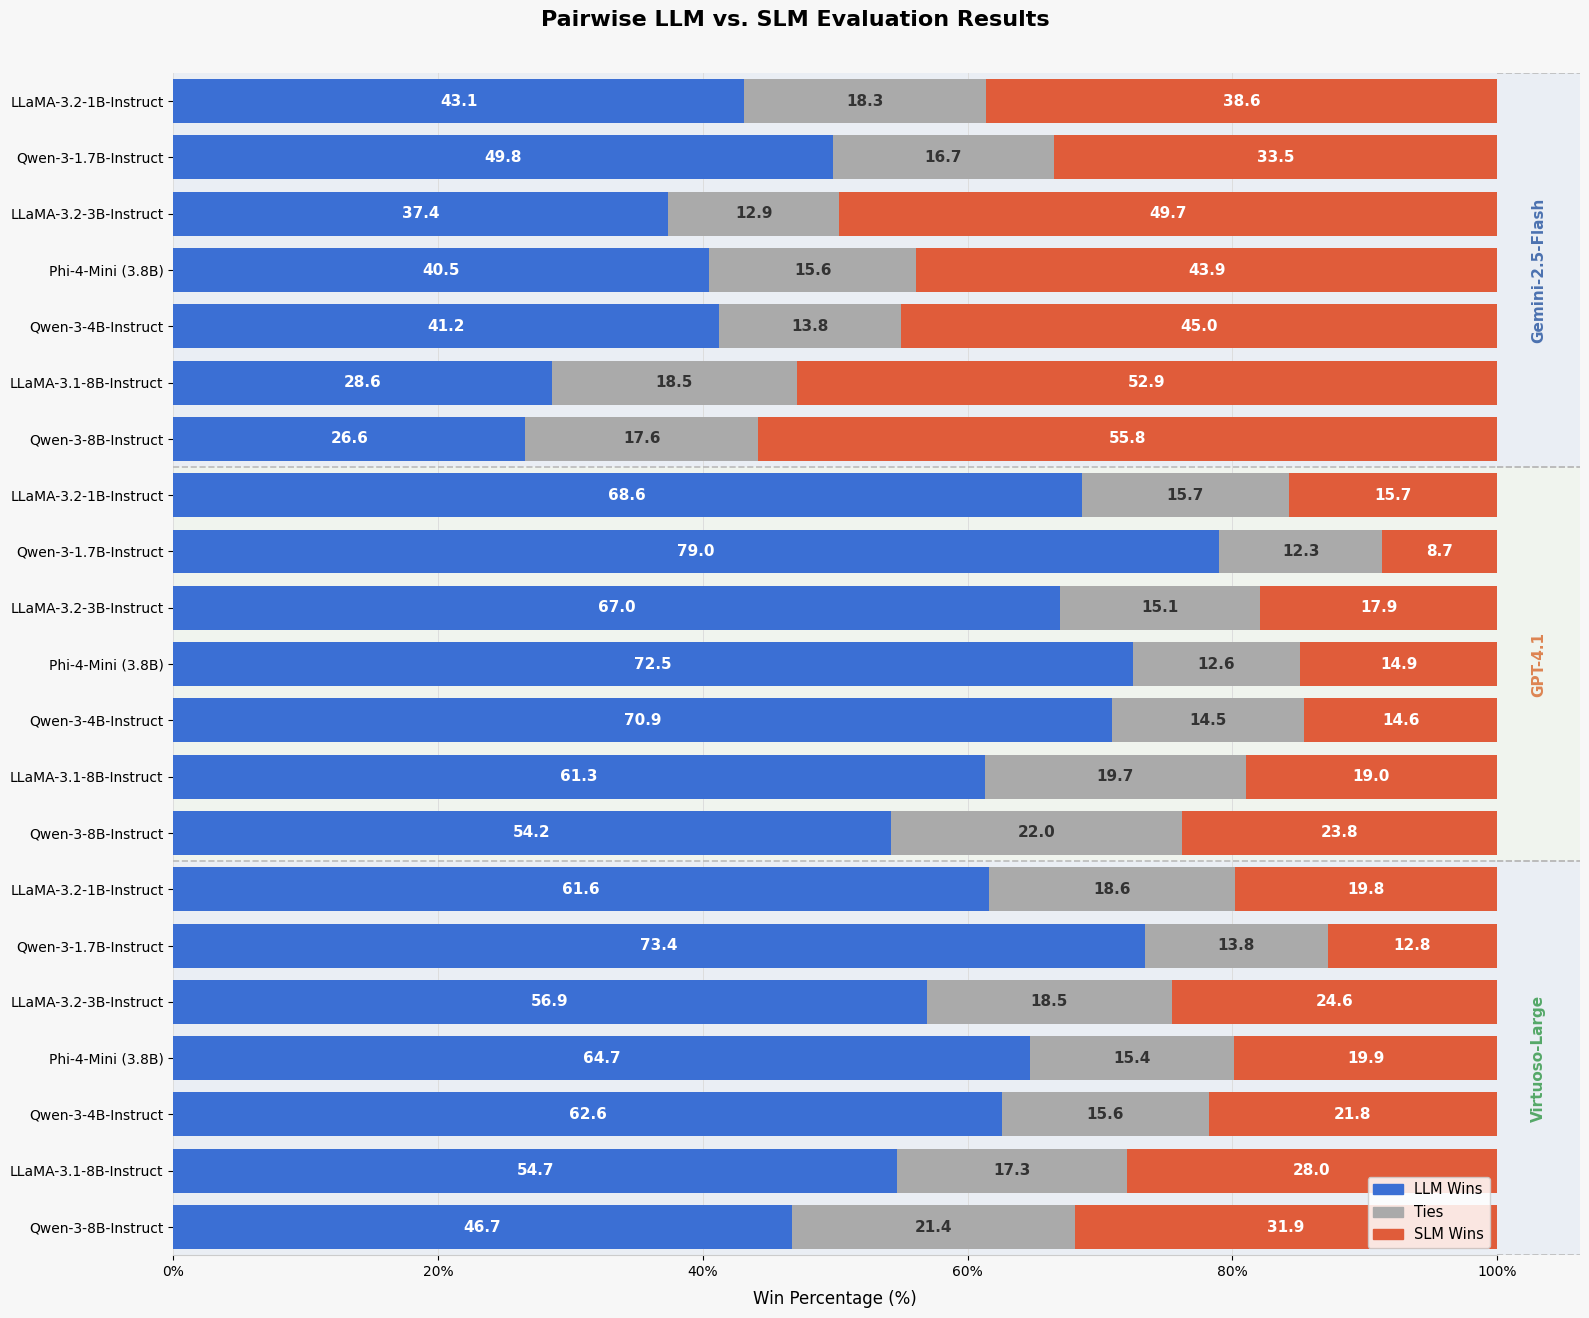

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

data = [
    ("Gemini-2.5-Flash", "LLaMA-3.2-1B-Instruct",   43.10, 38.60, 18.30),
    ("Gemini-2.5-Flash", "Qwen-3-1.7B-Instruct",    49.80, 33.50, 16.70),
    ("Gemini-2.5-Flash", "LLaMA-3.2-3B-Instruct",   37.40, 49.70, 12.90),
    ("Gemini-2.5-Flash", "Phi-4-Mini (3.8B)",        40.50, 43.90, 15.60),
    ("Gemini-2.5-Flash", "Qwen-3-4B-Instruct",      41.20, 45.00, 13.80),
    ("Gemini-2.5-Flash", "LLaMA-3.1-8B-Instruct",   28.60, 52.90, 18.50),
    ("Gemini-2.5-Flash", "Qwen-3-8B-Instruct",      26.60, 55.80, 17.60),
    ("GPT-4.1",          "LLaMA-3.2-1B-Instruct",   68.60, 15.70, 15.70),
    ("GPT-4.1",          "Qwen-3-1.7B-Instruct",    79.00,  8.70, 12.30),
    ("GPT-4.1",          "LLaMA-3.2-3B-Instruct",   67.00, 17.90, 15.10),
    ("GPT-4.1",          "Phi-4-Mini (3.8B)",        72.50, 14.90, 12.60),
    ("GPT-4.1",          "Qwen-3-4B-Instruct",      70.90, 14.60, 14.50),
    ("GPT-4.1",          "LLaMA-3.1-8B-Instruct",   61.30, 19.00, 19.70),
    ("GPT-4.1",          "Qwen-3-8B-Instruct",      54.20, 23.80, 22.00),
    ("Virtuoso-Large",   "LLaMA-3.2-1B-Instruct",   61.60, 19.80, 18.60),
    ("Virtuoso-Large",   "Qwen-3-1.7B-Instruct",    73.40, 12.80, 13.80),
    ("Virtuoso-Large",   "LLaMA-3.2-3B-Instruct",   56.90, 24.60, 18.50),
    ("Virtuoso-Large",   "Phi-4-Mini (3.8B)",        64.70, 19.90, 15.40),
    ("Virtuoso-Large",   "Qwen-3-4B-Instruct",      62.60, 21.80, 15.60),
    ("Virtuoso-Large",   "LLaMA-3.1-8B-Instruct",   54.70, 28.00, 17.30),
    ("Virtuoso-Large",   "Qwen-3-8B-Instruct",      46.70, 31.90, 21.40),
]

slms  = [d[1] for d in data]
llm_w = np.array([d[2] for d in data])
slm_w = np.array([d[3] for d in data])
ties  = np.array([d[4] for d in data])
n     = len(data)
y     = np.arange(n)

llm_groups   = ["Gemini-2.5-Flash", "GPT-4.1", "Virtuoso-Large"]
group_colors = {
    "Gemini-2.5-Flash": "#4C72B0",
    "GPT-4.1":          "#DD8452",
    "Virtuoso-Large":   "#55A868",
}
group_boundaries = [0, 7, 14, 21]

fig = plt.figure(figsize=(16, 13))
fig.patch.set_facecolor("#F7F7F7")

gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[16, 1], wspace=0.0)
ax     = fig.add_subplot(gs[0])
ax_lbl = fig.add_subplot(gs[1])

for a in (ax_lbl, ax):
    a.set_facecolor("#F7F7F7")

height = 0.78   # wider bars

for gi, llm in enumerate(llm_groups):
    lo, hi = group_boundaries[gi], group_boundaries[gi + 1]
    shade  = "#EAEEF4" if gi % 2 == 0 else "#F0F4EE"
    ax.axhspan(lo - 0.5, hi - 0.5, color=shade, zorder=0)

ax.barh(y, llm_w,                    height=height, color="#3B6FD4", zorder=3)
ax.barh(y, ties,  left=llm_w,        height=height, color="#AAAAAA", zorder=3)
ax.barh(y, slm_w, left=llm_w + ties, height=height, color="#E05C3A", zorder=3)

# Larger value labels
for i in range(n):
    if llm_w[i] >= 7:
        ax.text(llm_w[i] / 2, i, f"{llm_w[i]:.1f}",
                ha="center", va="center", fontsize=11, color="white", fontweight="bold", zorder=4)
    if ties[i] >= 7:
        ax.text(llm_w[i] + ties[i] / 2, i, f"{ties[i]:.1f}",
                ha="center", va="center", fontsize=11, color="#333333", fontweight="bold", zorder=4)
    if slm_w[i] >= 7:
        ax.text(llm_w[i] + ties[i] + slm_w[i] / 2, i, f"{slm_w[i]:.1f}",
                ha="center", va="center", fontsize=11, color="white", fontweight="bold", zorder=4)

for b in group_boundaries[1:-1]:
    ax.axhline(b - 0.5, color="#BBBBBB", linewidth=1.2, linestyle="--", zorder=2)

ax.set_yticks(y)
ax.set_yticklabels(slms, fontsize=10)
ax.set_ylim(n - 0.5, -0.5)
ax.set_xlim(0, 100)
ax.set_xlabel("Win Percentage (%)", fontsize=12, labelpad=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
ax.tick_params(axis="x", labelsize=10)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")
ax.grid(axis="x", color="#DDDDDD", linewidth=0.7, zorder=1)

legend_patches = [
    mpatches.Patch(color="#3B6FD4", label="LLM Wins"),
    mpatches.Patch(color="#AAAAAA", label="Ties"),
    mpatches.Patch(color="#E05C3A", label="SLM Wins"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=10.5,
          framealpha=0.85, edgecolor="#CCCCCC")

# Right label strip
ax_lbl.set_xlim(0, 1)
ax_lbl.set_ylim(n - 0.5, -0.5)
ax_lbl.axis("off")

for gi, llm in enumerate(llm_groups):
    lo, hi = group_boundaries[gi], group_boundaries[gi + 1]
    mid    = (lo + hi - 1) / 2
    shade  = "#EAEEF4" if gi % 2 == 0 else "#F0F4EE"
    ax_lbl.axhspan(lo - 0.5, hi - 0.5, color=shade, zorder=0)
    ax_lbl.text(0.5, mid, llm, ha="center", va="center", rotation=90,
                fontsize=11, fontweight="bold", color=group_colors[llm], zorder=2)
    for edge in [lo - 0.5, hi - 0.5]:
        ax_lbl.axhline(edge, color="#BBBBBB", linewidth=1.2, linestyle="--", zorder=1)

fig.suptitle("Pairwise LLM vs. SLM Evaluation Results",
             fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()

## Comparison of Lexical and Semantic Similarity (Scores Mentioned Outside)

/tmp/ipykernel_147/3090393973.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


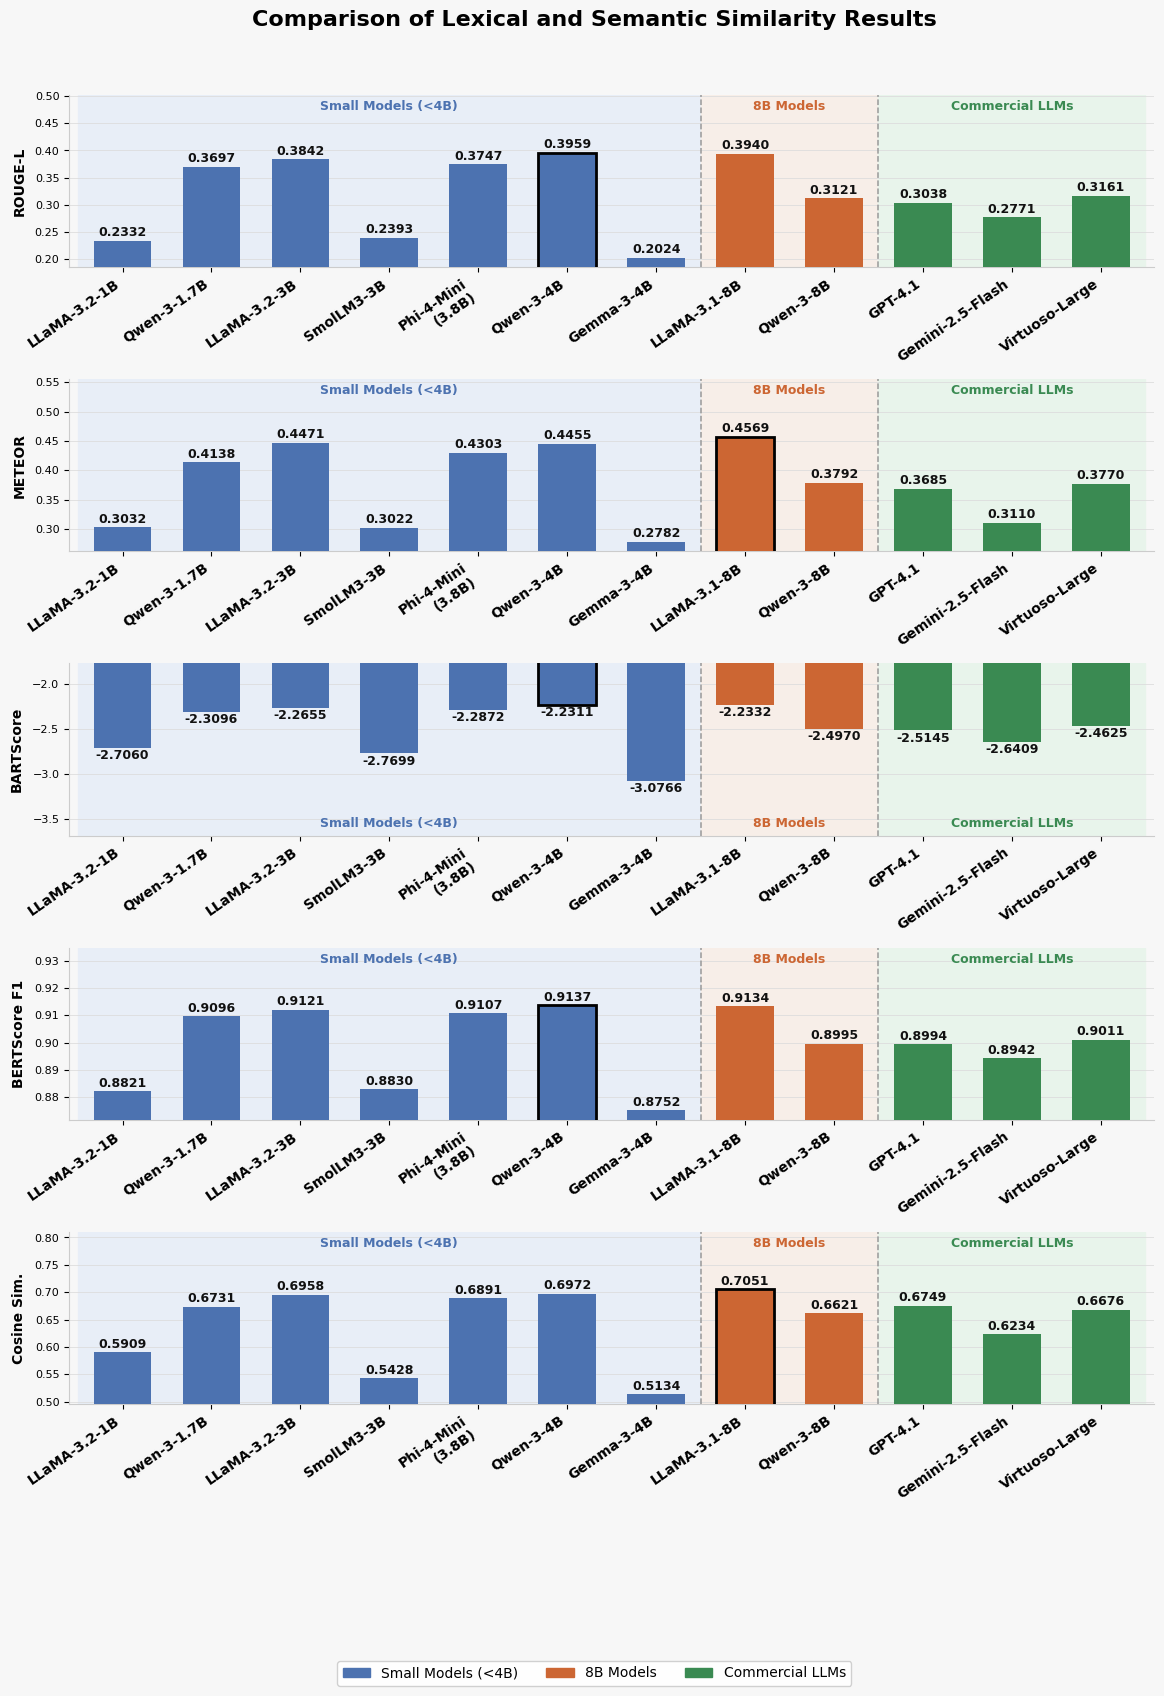

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

rows = [
    ("LLaMA-3.2-1B",      0.2332, 0.3032, -2.7060, 0.8821, 0.5909, "small"),
    ("Qwen-3-1.7B",       0.3697, 0.4138, -2.3096, 0.9096, 0.6731, "small"),
    ("LLaMA-3.2-3B",      0.3842, 0.4471, -2.2655, 0.9121, 0.6958, "small"),
    ("SmolLM3-3B",        0.2393, 0.3022, -2.7699, 0.8830, 0.5428, "small"),
    ("Phi-4-Mini\n(3.8B)",0.3747, 0.4303, -2.2872, 0.9107, 0.6891, "small"),
    ("Qwen-3-4B",         0.3959, 0.4455, -2.2311, 0.9137, 0.6972, "small"),
    ("Gemma-3-4B",        0.2024, 0.2782, -3.0766, 0.8752, 0.5134, "small"),
    ("LLaMA-3.1-8B",      0.3940, 0.4569, -2.2332, 0.9134, 0.7051, "8b"),
    ("Qwen-3-8B",         0.3121, 0.3792, -2.4970, 0.8995, 0.6621, "8b"),
    ("GPT-4.1",           0.3038, 0.3685, -2.5145, 0.8994, 0.6749, "llm"),
    ("Gemini-2.5-Flash",  0.2771, 0.3110, -2.6409, 0.8942, 0.6234, "llm"),
    ("Virtuoso-Large",    0.3161, 0.3770, -2.4625, 0.9011, 0.6676, "llm"),
]

models   = [r[0] for r in rows]
groups_k = [r[6] for r in rows]

metrics  = ["ROUGE-L", "METEOR", "BARTScore", "BERTScore F1", "Cosine Sim."]
vals     = {m: np.array([r[i+1] for r in rows]) for i, m in enumerate(metrics)}

best = {
    "ROUGE-L":      "Qwen-3-4B",
    "METEOR":       "LLaMA-3.1-8B",
    "BARTScore":    "Qwen-3-4B",
    "BERTScore F1": "Qwen-3-4B",
    "Cosine Sim.":  "LLaMA-3.1-8B",
}

group_info = [
    ("small", "Small Models (<4B)", "#4C72B0", "#E8EEF7"),
    ("8b",    "8B Models",          "#CC6633", "#F7EEE8"),
    ("llm",   "Commercial LLMs",    "#3A8A52", "#E8F4EB"),
]

n     = len(models)
x     = np.arange(n)
bar_w = 0.65

spans = {}
for k, *_ in group_info:
    idxs = [i for i, g in enumerate(groups_k) if g == k]
    spans[k] = (min(idxs), max(idxs))

fig, axes = plt.subplots(
    5, 1,
    figsize=(14, 17),
    gridspec_kw={"hspace": 0.65}   # increased spacing
)

fig.patch.set_facecolor("#F7F7F7")

for metric, ax in zip(metrics, axes):

    ax.set_facecolor("#F7F7F7")

    v = vals[metric]

    ylo, yhi = v.min(), v.max()
    rng = yhi - ylo if yhi != ylo else 0.01
    pad = rng * 0.18

    if metric == "BARTScore":
        ylim_lo = ylo - pad * 4
        ylim_hi = yhi + rng * 0.55
    else:
        ylim_lo = ylo - pad * 0.5
        ylim_hi = yhi + rng * 0.55

    ax.set_ylim(ylim_lo, ylim_hi)

    for k, label, color, shade in group_info:

        lo, hi = spans[k]

        ax.axvspan(lo - 0.5, hi + 0.5, color=shade, zorder=0)

        idxs = list(range(lo, hi + 1))
        ax.bar(idxs, v[idxs], width=bar_w, color=color, zorder=3)

        bm = best.get(metric)

        if bm and bm in models:

            bi = models.index(bm)

            if lo <= bi <= hi:

                ax.bar(
                    bi,
                    v[bi],
                    width=bar_w,
                    color=color,
                    edgecolor="black",
                    linewidth=2.0,
                    zorder=4
                )

    for k, *_ in group_info[:-1]:

        _, hi = spans[k]

        ax.axvline(
            hi + 0.5,
            color="#999999",
            linewidth=1.1,
            linestyle="--",
            zorder=2
        )

    if metric == "BARTScore":
        label_y = ylim_lo + (ylim_hi - ylim_lo) * 0.03
        label_va = "bottom"
    else:
        label_y = ylim_hi - (ylim_hi - ylim_lo) * 0.03
        label_va = "top"

    for k, label, color, shade in group_info:

        lo, hi = spans[k]
        mid_x = (lo + hi) / 2.0

        ax.text(
            mid_x,
            label_y,
            label,
            ha="center",
            va=label_va,
            fontsize=9,
            fontweight="bold",
            color=color
        )

    offset = rng * 0.015

    for i, val in enumerate(v):

        above = metric != "BARTScore"

        ax.text(
            i,
            val + (offset if above else -offset),
            f"{val:.4f}",
            ha="center",
            va="bottom" if above else "top",
            fontsize=9,
            fontweight="bold",
            color="#111111",
            zorder=5
        )

    ax.set_ylabel(metric, fontsize=10, fontweight="bold", labelpad=6)

    ax.tick_params(axis="y", labelsize=8)

    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_color("#CCCCCC")

    ax.grid(axis="y", color="#DDDDDD", linewidth=0.6, zorder=1)

    ax.set_xlim(-0.6, n - 0.4)

    ax.set_xticks(x)

    ax.set_xticklabels(
        models,
        rotation=35,
        ha="right",
        fontsize=10,
        fontweight="bold"
    )

fig.suptitle(
    "Comparison of Lexical and Semantic Similarity Results",
    fontsize=16,
    fontweight="bold",
    y=0.93
)

legend_patches = [
    mpatches.Patch(color=c, label=l)
    for k, l, c, s in group_info
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=3,
    fontsize=10,
    framealpha=0.9,
    edgecolor="#CCCCCC",
    bbox_to_anchor=(0.5, -0.06)
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## LLM-as-a-judge Evaluation Results (Scores Mentioned Outside)

/tmp/ipykernel_147/3746617824.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


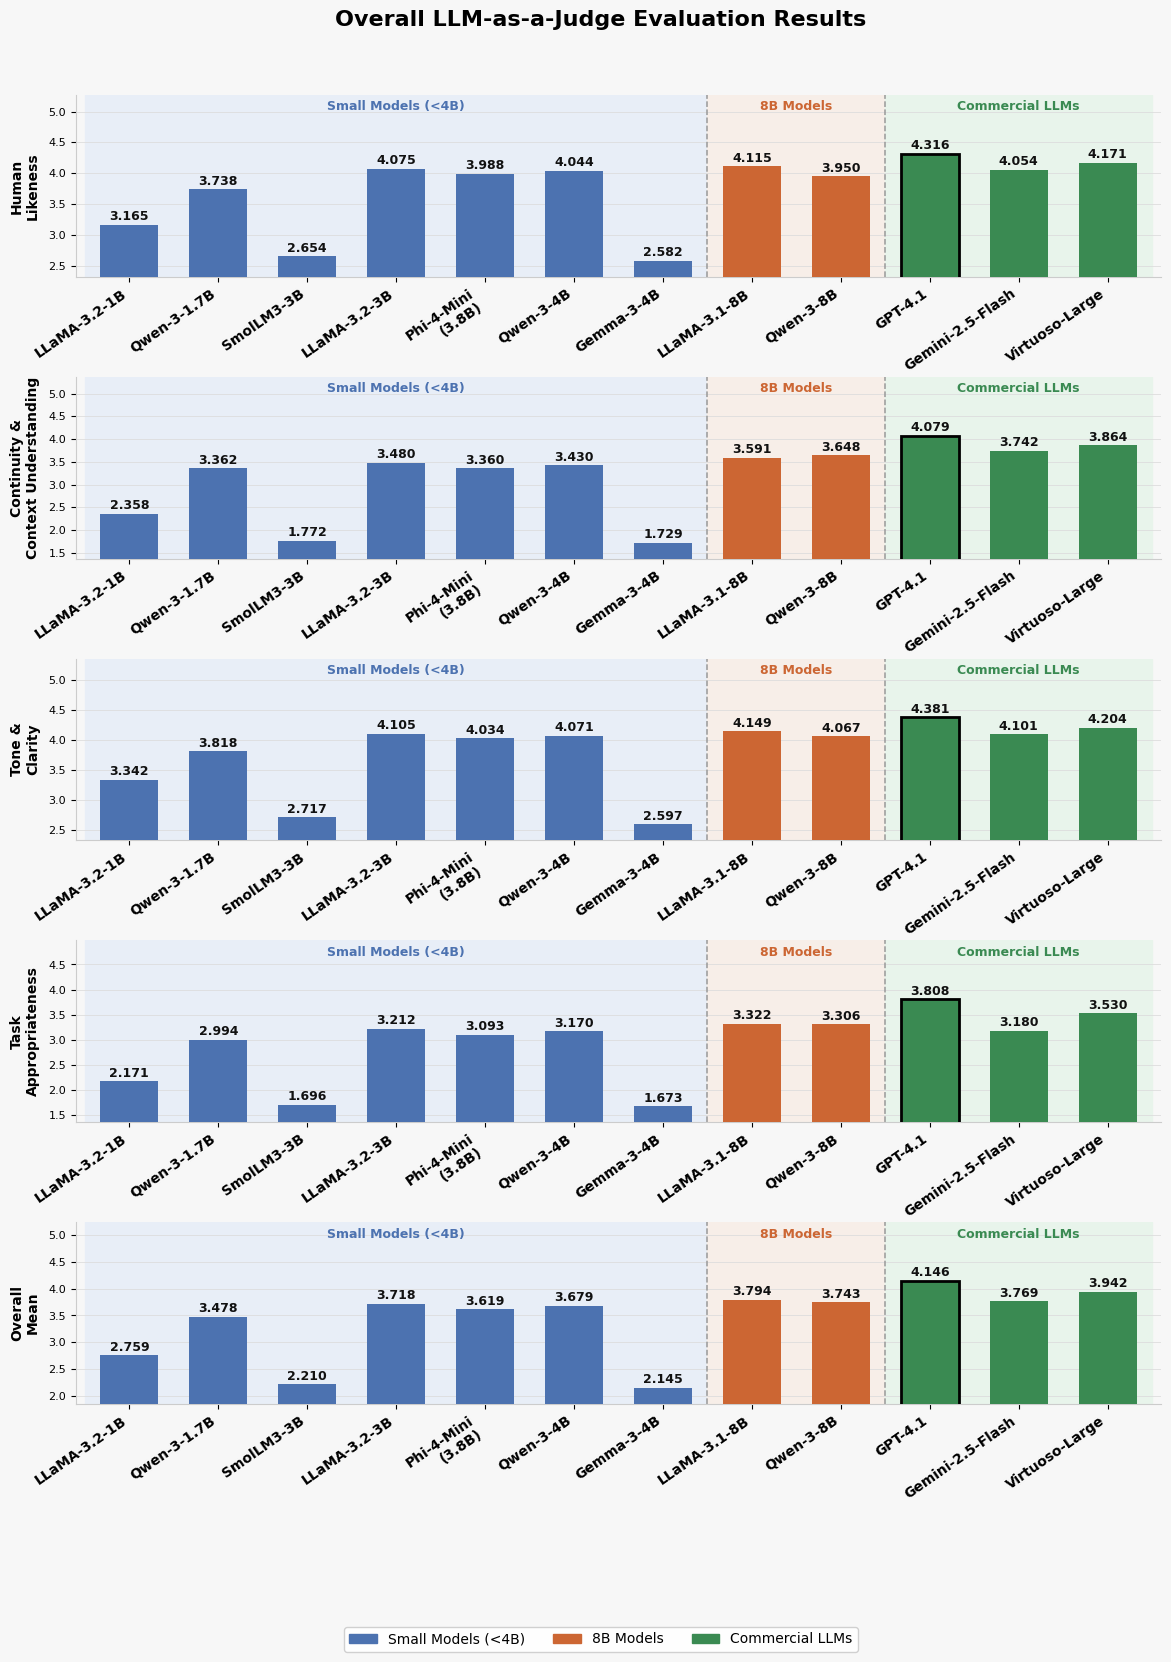

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data
rows = [
    ("LLaMA-3.2-1B",      3.165, 2.358, 3.342, 2.171, 2.759, "small"),
    ("Qwen-3-1.7B",       3.738, 3.362, 3.818, 2.994, 3.478, "small"),
    ("SmolLM3-3B",        2.654, 1.772, 2.717, 1.696, 2.210, "small"),
    ("LLaMA-3.2-3B",      4.075, 3.480, 4.105, 3.212, 3.718, "small"),
    ("Phi-4-Mini\n(3.8B)",3.988, 3.360, 4.034, 3.093, 3.619, "small"),
    ("Qwen-3-4B",         4.044, 3.430, 4.071, 3.170, 3.679, "small"),
    ("Gemma-3-4B",        2.582, 1.729, 2.597, 1.673, 2.145, "small"),
    ("LLaMA-3.1-8B",      4.115, 3.591, 4.149, 3.322, 3.794, "8b"),
    ("Qwen-3-8B",         3.950, 3.648, 4.067, 3.306, 3.743, "8b"),
    ("GPT-4.1",           4.316, 4.079, 4.381, 3.808, 4.146, "llm"),
    ("Gemini-2.5-Flash",  4.054, 3.742, 4.101, 3.180, 3.769, "llm"),
    ("Virtuoso-Large",    4.171, 3.864, 4.204, 3.530, 3.942, "llm"),
]

models   = [r[0] for r in rows]
groups_k = [r[6] for r in rows]

metrics  = [
    "Human\nLikeness",
    "Continuity &\nContext Understanding",
    "Tone &\nClarity",
    "Task\nAppropriateness",
    "Overall\nMean"
]

vals = {m: np.array([r[i+1] for r in rows]) for i, m in enumerate(metrics)}

best = {m: models[int(np.argmax(vals[m]))] for m in metrics}

group_info = [
    ("small", "Small Models (<4B)", "#4C72B0", "#E8EEF7"),
    ("8b",    "8B Models",          "#CC6633", "#F7EEE8"),
    ("llm",   "Commercial LLMs",    "#3A8A52", "#E8F4EB"),
]

n     = len(models)
x     = np.arange(n)
bar_w = 0.65

spans = {}
for k, *_ in group_info:
    idxs = [i for i, g in enumerate(groups_k) if g == k]
    spans[k] = (min(idxs), max(idxs))

fig, axes = plt.subplots(
    5, 1,
    figsize=(14, 17),
    gridspec_kw={"hspace": 0.55}
)

fig.patch.set_facecolor("#F7F7F7")

for mi, (metric, ax) in enumerate(zip(metrics, axes)):

    ax.set_facecolor("#F7F7F7")

    v = vals[metric]

    ylo, yhi = v.min(), v.max()
    rng = yhi - ylo if yhi != ylo else 0.01

    ylim_lo = max(0, ylo - rng * 0.15)
    ylim_hi = yhi + rng * 0.55
    ax.set_ylim(ylim_lo, ylim_hi)

    # group shading & bars
    for k, label, color, shade in group_info:

        lo, hi = spans[k]

        ax.axvspan(lo - 0.5, hi + 0.5, color=shade, zorder=0)

        idxs = list(range(lo, hi + 1))

        ax.bar(idxs, v[idxs], width=bar_w, color=color, zorder=3)

        bm = best.get(metric)

        if bm and bm in models:

            bi = models.index(bm)

            if lo <= bi <= hi:
                ax.bar(
                    bi,
                    v[bi],
                    width=bar_w,
                    color=color,
                    edgecolor="black",
                    linewidth=2.0,
                    zorder=4
                )

    # separator lines
    for k, *_ in group_info[:-1]:
        _, hi = spans[k]
        ax.axvline(
            hi + 0.5,
            color="#999999",
            linewidth=1.1,
            linestyle="--",
            zorder=2
        )

    # group labels
    label_y = ylim_hi - (ylim_hi - ylim_lo) * 0.03

    for k, label, color, shade in group_info:

        lo, hi = spans[k]
        mid_x = (lo + hi) / 2.0

        ax.text(
            mid_x,
            label_y,
            label,
            ha="center",
            va="top",
            fontsize=9,
            fontweight="bold",
            color=color,
            zorder=6
        )

    # value labels
    offset = rng * 0.015

    for i, val in enumerate(v):

        ax.text(
            i,
            val + offset,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#111111",
            zorder=5
        )

    ax.set_ylabel(
        metric,
        fontsize=10,
        fontweight="bold",
        labelpad=6
    )

    ax.tick_params(axis="y", labelsize=8)

    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_color("#CCCCCC")

    ax.grid(
        axis="y",
        color="#DDDDDD",
        linewidth=0.6,
        zorder=1
    )

    ax.set_xlim(-0.6, n - 0.4)

    ax.set_xticks(x)

    # highlighted model names
    ax.set_xticklabels(
        models,
        rotation=35,
        ha="right",
        fontsize=10,
        fontweight="bold"
    )

fig.suptitle(
    "Overall LLM-as-a-Judge Evaluation Results\n",
    fontsize=16,
    fontweight="bold",
    y=0.93
)

legend_patches = [
    mpatches.Patch(color=c, label=l)
    for k, l, c, s in group_info
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=3,
    fontsize=10,
    framealpha=0.9,
    edgecolor="#CCCCCC",
    bbox_to_anchor=(0.5, -0.04)
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## Overall Human Evaluation Results

/tmp/ipykernel_147/1067484873.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


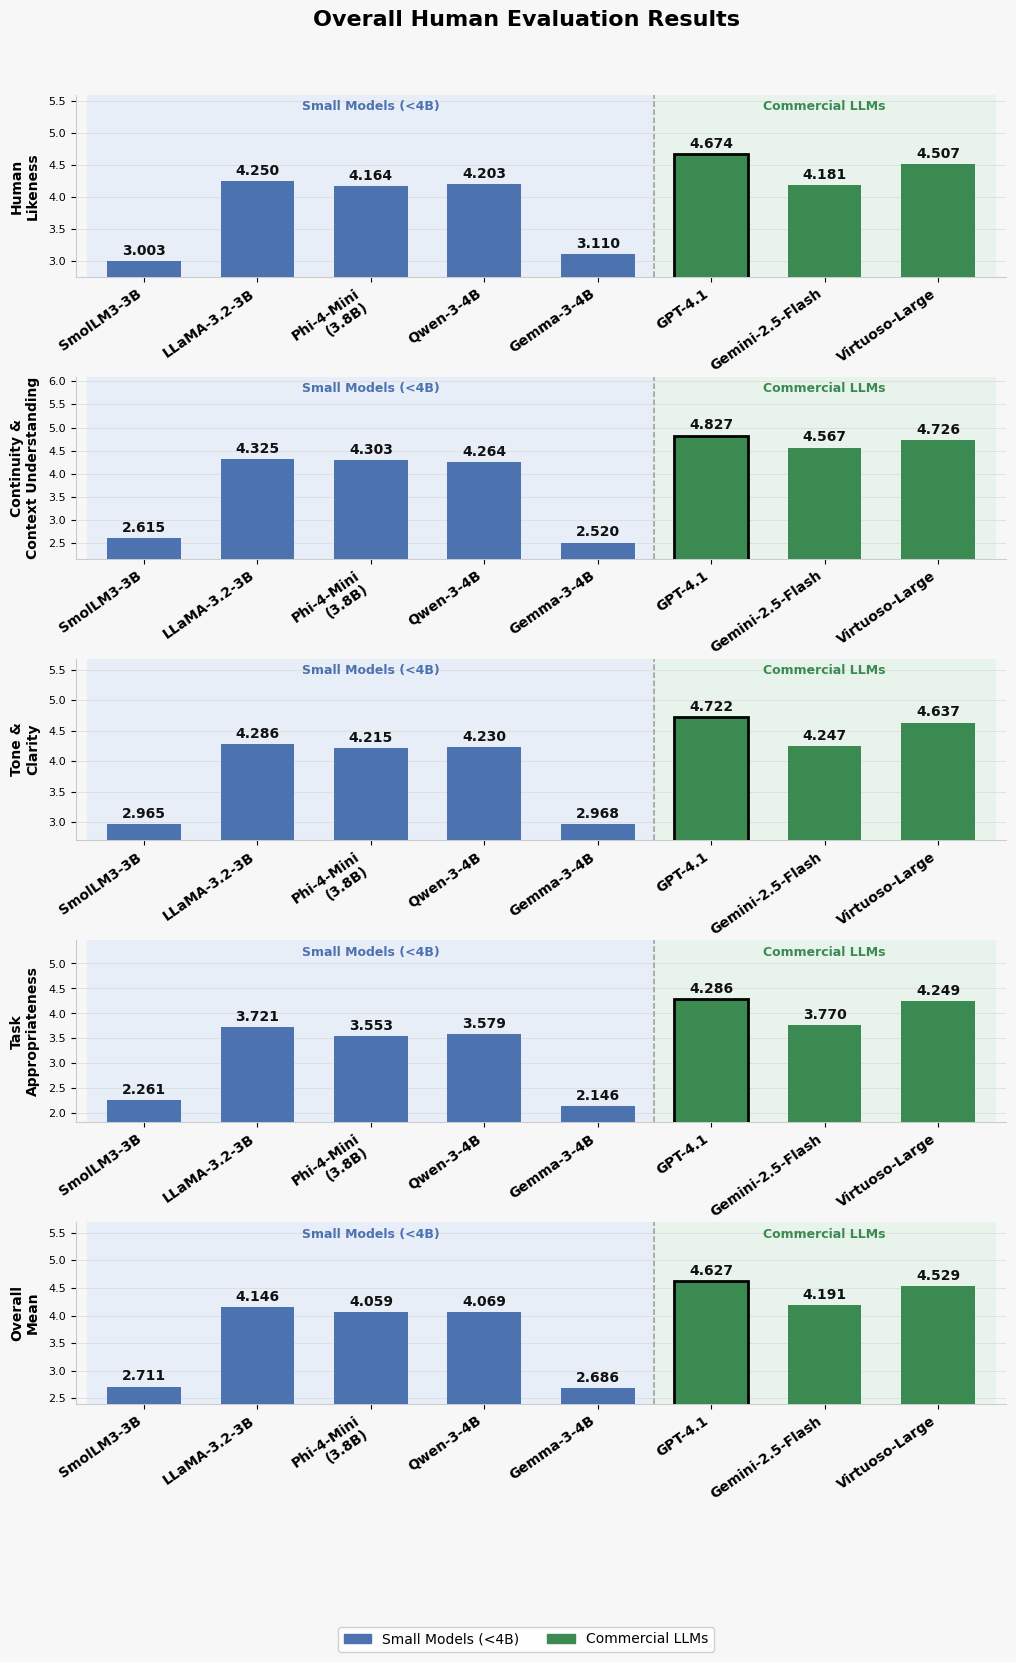

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data (Table 7.3) ──────────────────────────────────────────────────────────
rows = [
    ("SmolLM3-3B",        3.003, 2.615, 2.965, 2.261, 2.711, "small"),
    ("LLaMA-3.2-3B",      4.250, 4.325, 4.286, 3.721, 4.146, "small"),
    ("Phi-4-Mini\n(3.8B)",4.164, 4.303, 4.215, 3.553, 4.059, "small"),
    ("Qwen-3-4B",         4.203, 4.264, 4.230, 3.579, 4.069, "small"),
    ("Gemma-3-4B",        3.110, 2.520, 2.968, 2.146, 2.686, "small"),
    ("GPT-4.1",           4.674, 4.827, 4.722, 4.286, 4.627, "llm"),
    ("Gemini-2.5-Flash",  4.181, 4.567, 4.247, 3.770, 4.191, "llm"),
    ("Virtuoso-Large",    4.507, 4.726, 4.637, 4.249, 4.529, "llm"),
]

models   = [r[0] for r in rows]
groups_k = [r[6] for r in rows]

metrics  = [
    "Human\nLikeness",
    "Continuity &\nContext Understanding",
    "Tone &\nClarity",
    "Task\nAppropriateness",
    "Overall\nMean",
]

vals = {m: np.array([r[i+1] for r in rows]) for i, m in enumerate(metrics)}
best = {m: models[int(np.argmax(vals[m]))] for m in metrics}

group_info = [
    ("small", "Small Models (<4B)", "#4C72B0", "#E8EEF7"),
    ("llm",   "Commercial LLMs",    "#3A8A52", "#E8F4EB"),
]

n     = len(models)
x     = np.arange(n)
bar_w = 0.65

spans = {}
for k, *_ in group_info:
    idxs = [i for i, g in enumerate(groups_k) if g == k]
    spans[k] = (min(idxs), max(idxs))

fig, axes = plt.subplots(5, 1, figsize=(12, 17),
                         gridspec_kw={"hspace": 0.55})
fig.patch.set_facecolor("#F7F7F7")

for mi, (metric, ax) in enumerate(zip(metrics, axes)):

    ax.set_facecolor("#F7F7F7")

    v = vals[metric]
    ylo, yhi = v.min(), v.max()
    rng = yhi - ylo if yhi != ylo else 0.01

    ylim_lo = max(0, ylo - rng * 0.15)
    ylim_hi = yhi + rng * 0.55
    ax.set_ylim(ylim_lo, ylim_hi)

    # group shading & bars
    for k, label, color, shade in group_info:

        lo, hi = spans[k]

        ax.axvspan(lo - 0.5, hi + 0.5, color=shade, zorder=0)

        idxs = list(range(lo, hi + 1))
        ax.bar(idxs, v[idxs], width=bar_w, color=color, zorder=3)

        bm = best.get(metric)

        if bm and bm in models:
            bi = models.index(bm)
            if lo <= bi <= hi:
                ax.bar(bi, v[bi],
                       width=bar_w,
                       color=color,
                       edgecolor="black",
                       linewidth=2.0,
                       zorder=4)

    # separator lines
    for k, *_ in group_info[:-1]:
        _, hi = spans[k]
        ax.axvline(hi + 0.5,
                   color="#999999",
                   linewidth=1.1,
                   linestyle="--",
                   zorder=2)

    # group labels
    label_y = ylim_hi - (ylim_hi - ylim_lo) * 0.03

    for k, label, color, shade in group_info:
        lo, hi = spans[k]
        ax.text((lo + hi) / 2.0,
                label_y,
                label,
                ha="center",
                va="top",
                fontsize=9,
                fontweight="bold",
                color=color)

    # value labels
    offset = rng * 0.03

    for i, val in enumerate(v):
        ax.text(i,
                val + offset,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
                color="#111111",
                zorder=5)

    ax.set_ylabel(metric,
                  fontsize=10,
                  fontweight="bold",
                  labelpad=6)

    ax.tick_params(axis="y", labelsize=8)

    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_color("#CCCCCC")

    ax.grid(axis="y", color="#DDDDDD", linewidth=0.6, zorder=1)

    ax.set_xlim(-0.6, n - 0.4)
    ax.set_xticks(x)

    # highlighted model names
    ax.set_xticklabels(
        models,
        rotation=35,
        ha="right",
        fontsize=10,
        fontweight="bold"
    )

fig.suptitle(
    "Overall Human Evaluation Results\n",
    fontsize=16,
    fontweight="bold",
    y=0.93
)

legend_patches = [
    mpatches.Patch(color=c, label=l)
    for k, l, c, s in group_info
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=2,
    fontsize=10,
    framealpha=0.9,
    edgecolor="#CCCCCC",
    bbox_to_anchor=(0.5, -0.04)
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## Conversation Stage-based LLM-as-a-Judge Evaluation Results

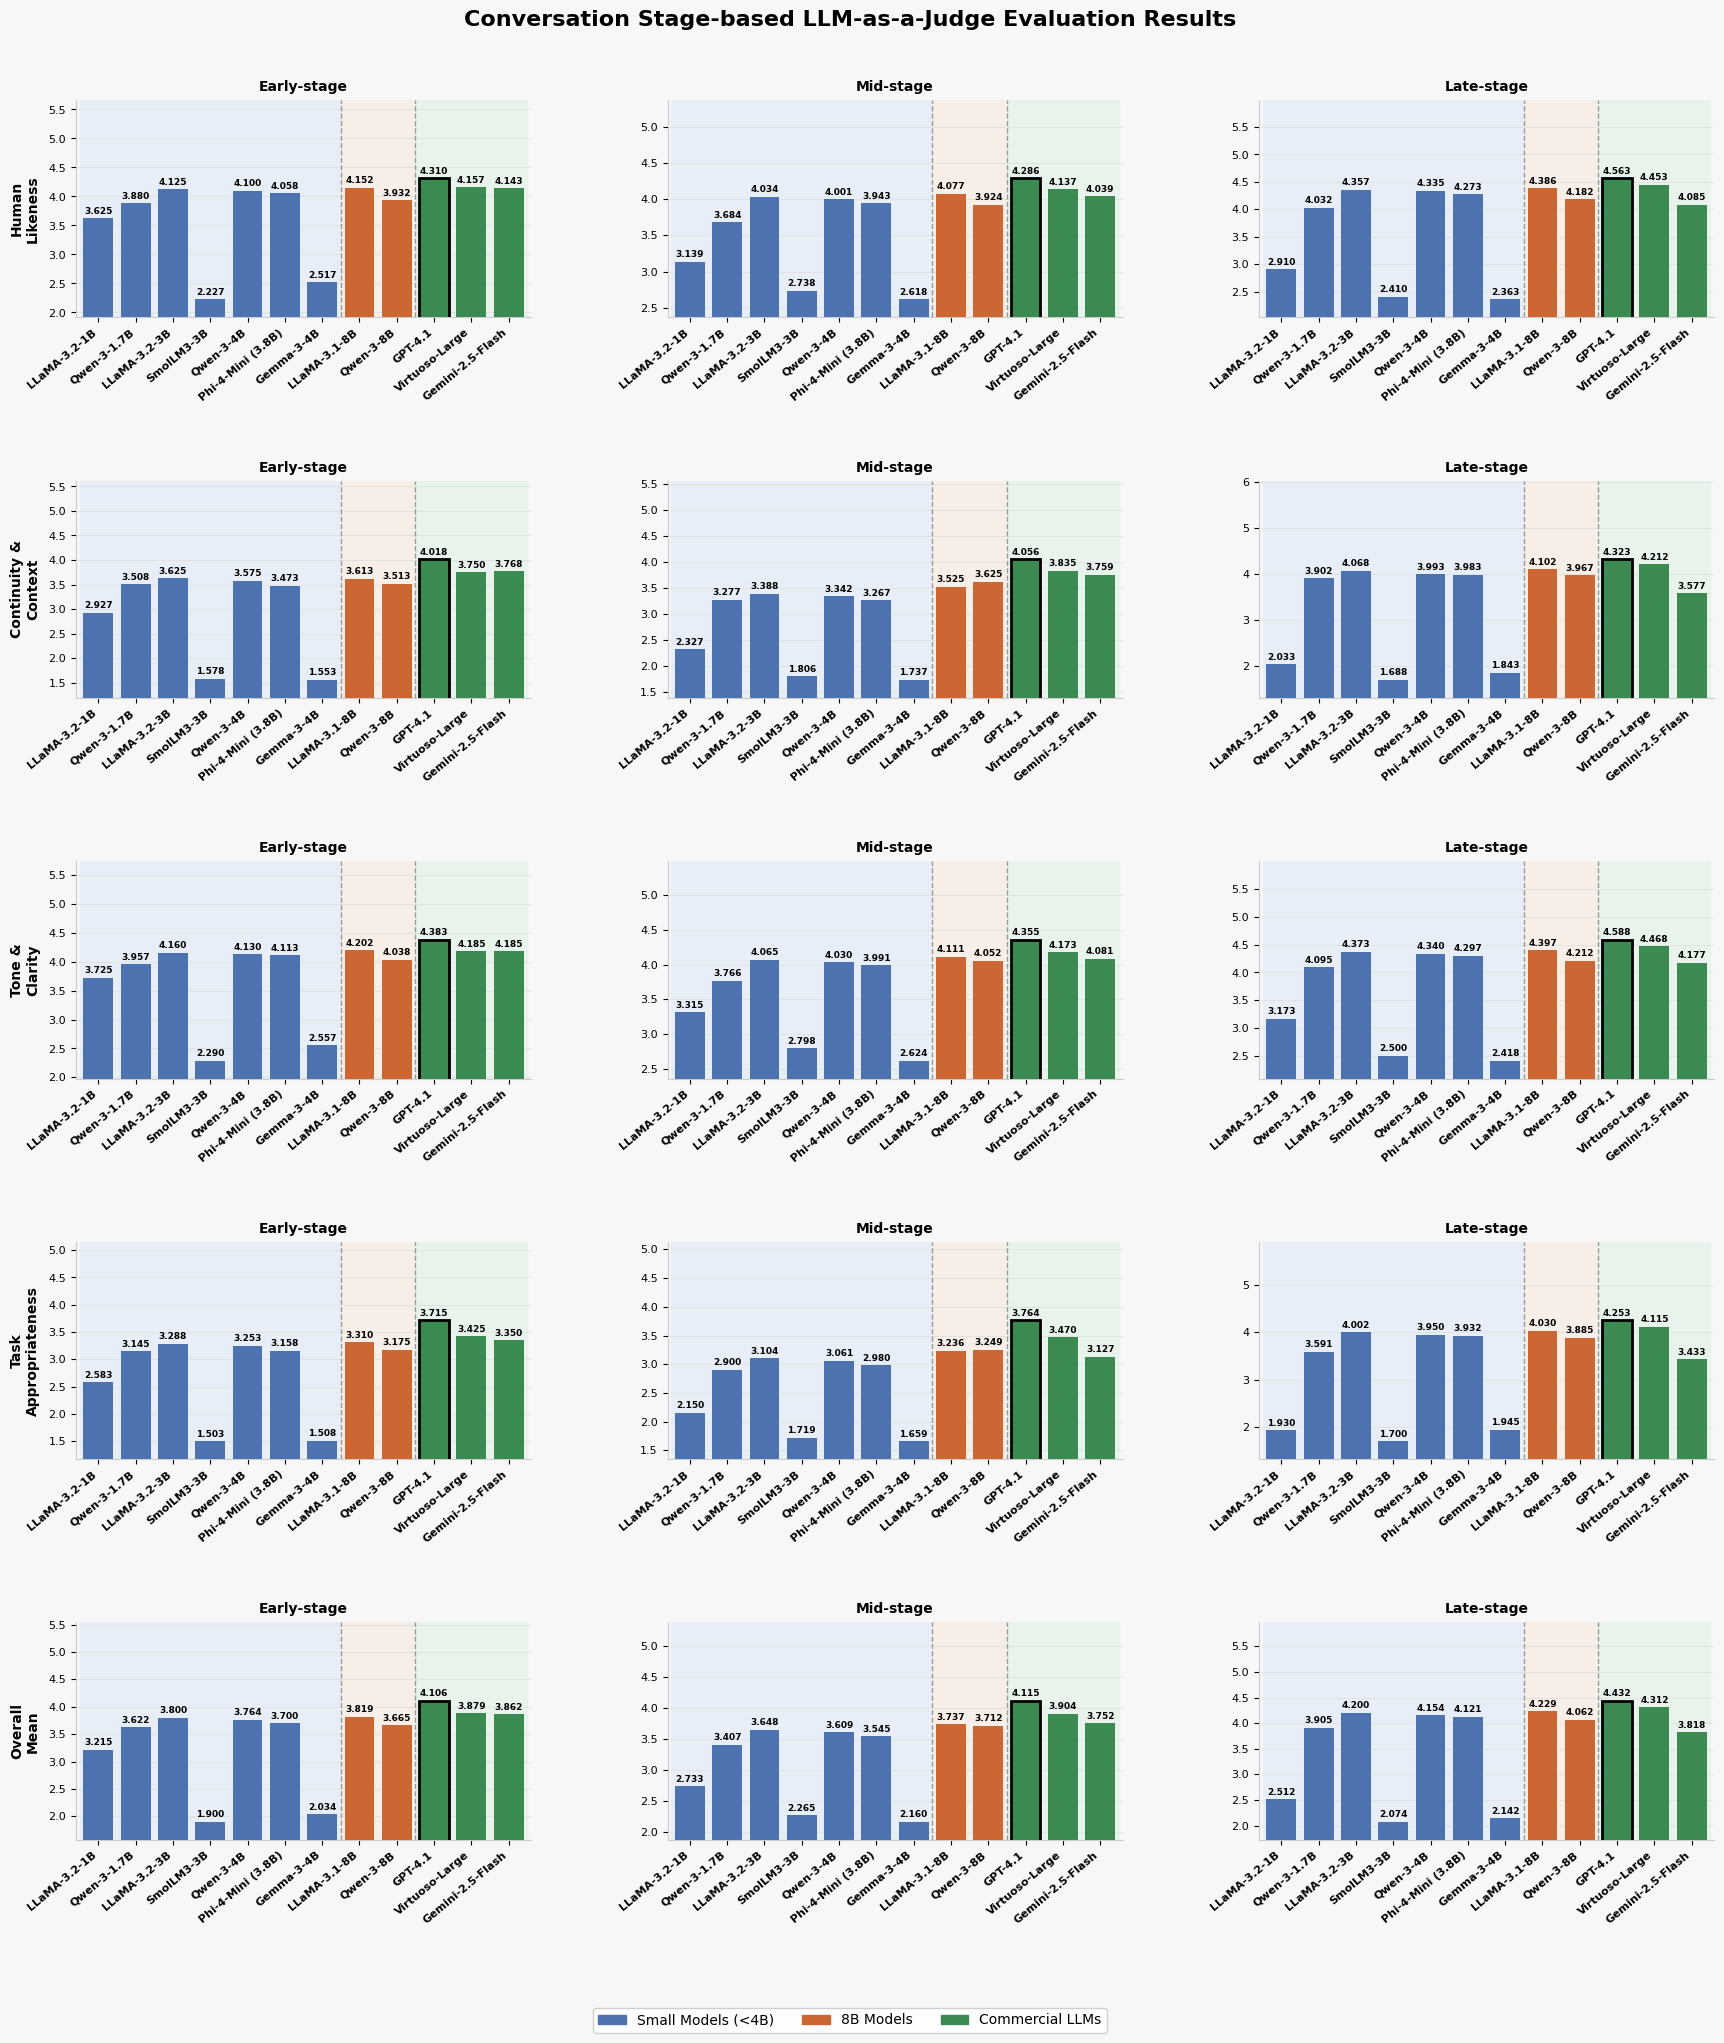

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.gridspec import GridSpec

data = {
    "Early-stage": [
        ("LLaMA-3.2-1B",  3.625, 2.927, 3.725, 2.583, 3.215, "small"),
        ("Qwen-3-1.7B",   3.880, 3.508, 3.957, 3.145, 3.622, "small"),
        ("LLaMA-3.2-3B",  4.125, 3.625, 4.160, 3.288, 3.800, "small"),
        ("SmolLM3-3B",    2.227, 1.578, 2.290, 1.503, 1.900, "small"),
        ("Qwen-3-4B",     4.100, 3.575, 4.130, 3.253, 3.764, "small"),
        ("Phi-4-Mini (3.8B)", 4.058, 3.473, 4.113, 3.158, 3.700, "small"),
        ("Gemma-3-4B",    2.517, 1.553, 2.557, 1.508, 2.034, "small"),
        ("LLaMA-3.1-8B",  4.152, 3.613, 4.202, 3.310, 3.819, "8b"),
        ("Qwen-3-8B",     3.932, 3.513, 4.038, 3.175, 3.665, "8b"),
        ("GPT-4.1",       4.310, 4.018, 4.383, 3.715, 4.106, "llm"),
        ("Virtuoso-Large",4.157, 3.750, 4.185, 3.425, 3.879, "llm"),
        ("Gemini-2.5-Flash",4.143, 3.768, 4.185, 3.350, 3.862, "llm"),
    ],

    "Mid-stage": [
        ("LLaMA-3.2-1B",  3.139, 2.327, 3.315, 2.150, 2.733, "small"),
        ("Qwen-3-1.7B",   3.684, 3.277, 3.766, 2.900, 3.407, "small"),
        ("LLaMA-3.2-3B",  4.034, 3.388, 4.065, 3.104, 3.648, "small"),
        ("SmolLM3-3B",    2.738, 1.806, 2.798, 1.719, 2.265, "small"),
        ("Qwen-3-4B",     4.001, 3.342, 4.030, 3.061, 3.609, "small"),
        ("Phi-4-Mini (3.8B)",3.943, 3.267, 3.991, 2.980, 3.545, "small"),
        ("Gemma-3-4B",    2.618, 1.737, 2.624, 1.659, 2.160, "small"),
        ("LLaMA-3.1-8B",  4.077, 3.525, 4.111, 3.236, 3.737, "8b"),
        ("Qwen-3-8B",     3.924, 3.625, 4.052, 3.249, 3.712, "8b"),
        ("GPT-4.1",       4.286, 4.056, 4.355, 3.764, 4.115, "llm"),
        ("Virtuoso-Large",4.137, 3.835, 4.173, 3.470, 3.904, "llm"),
        ("Gemini-2.5-Flash",4.039, 3.759, 4.081, 3.127, 3.752, "llm"),
    ],

    "Late-stage": [
        ("LLaMA-3.2-1B",  2.910, 2.033, 3.173, 1.930, 2.512, "small"),
        ("Qwen-3-1.7B",   4.032, 3.902, 4.095, 3.591, 3.905, "small"),
        ("LLaMA-3.2-3B",  4.357, 4.068, 4.373, 4.002, 4.200, "small"),
        ("SmolLM3-3B",    2.410, 1.688, 2.500, 1.700, 2.074, "small"),
        ("Qwen-3-4B",     4.335, 3.993, 4.340, 3.950, 4.154, "small"),
        ("Phi-4-Mini (3.8B)",4.273, 3.983, 4.297, 3.932, 4.121, "small"),
        ("Gemma-3-4B",    2.363, 1.843, 2.418, 1.945, 2.142, "small"),
        ("LLaMA-3.1-8B",  4.386, 4.102, 4.397, 4.030, 4.229, "8b"),
        ("Qwen-3-8B",     4.182, 3.967, 4.212, 3.885, 4.062, "8b"),
        ("GPT-4.1",       4.563, 4.323, 4.588, 4.253, 4.432, "llm"),
        ("Virtuoso-Large",4.453, 4.212, 4.468, 4.115, 4.312, "llm"),
        ("Gemini-2.5-Flash",4.085, 3.577, 4.177, 3.433, 3.818, "llm"),
    ],
}

metrics = [
    "Human\nLikeness",
    "Continuity &\nContext",
    "Tone &\nClarity",
    "Task\nAppropriateness",
    "Overall\nMean",
]

stages = list(data.keys())

group_info = [
    ("small", "Small Models (<4B)", "#4C72B0", "#E8EEF7"),
    ("8b",    "8B Models",          "#CC6633", "#F7EEE8"),
    ("llm",   "Commercial LLMs",    "#3A8A52", "#E8F4EB"),
]

bar_w = 0.80

fig = plt.figure(figsize=(18,20))
fig.patch.set_facecolor("#F7F7F7")

gs = GridSpec(len(metrics), len(stages), figure=fig,
              hspace=0.75, wspace=0.30,
              top=0.93, bottom=0.06, left=0.07, right=0.98)

axes = [[fig.add_subplot(gs[mi, si]) for si in range(len(stages))]
        for mi in range(len(metrics))]

fig.canvas.draw()

for mi in range(len(metrics)):
    for si, stage in enumerate(stages):
        bbox = axes[mi][si].get_position()
        xmid = (bbox.x0 + bbox.x1) / 2
        fig.text(xmid, bbox.y1 + 0.003, stage,
                 ha="center", va="bottom",
                 fontsize=10, fontweight="bold")

fig.suptitle(
    "Conversation Stage-based LLM-as-a-Judge Evaluation Results\n",
    fontsize=16,
    fontweight="bold",
    y=0.975
)

for mi, metric in enumerate(metrics):
    for si, stage in enumerate(stages):

        ax = axes[mi][si]
        rows = data[stage]

        models = [r[0] for r in rows]
        groups = [r[6] for r in rows]
        values = np.array([r[mi+1] for r in rows])

        n = len(models)
        x = np.arange(n)

        ax.set_facecolor("#F7F7F7")

        spans = {}
        for k, *_ in group_info:
            idxs = [i for i,g in enumerate(groups) if g==k]
            if idxs:
                spans[k] = (min(idxs), max(idxs))

        ylo, yhi = values.min(), values.max()
        rng = yhi - ylo if yhi != ylo else 0.01

        ylim_lo = max(0, ylo - rng*0.15)
        ylim_hi = yhi + rng*0.65
        ax.set_ylim(ylim_lo, ylim_hi)

        bar_range = ylim_hi - ylim_lo

        best_i = int(np.argmax(values))

        for k,label,color,shade in group_info:
            if k not in spans:
                continue
            lo,hi = spans[k]
            ax.axvspan(lo-0.5,hi+0.5,color=shade,zorder=0)
            ax.bar(range(lo,hi+1),values[lo:hi+1],
                   width=bar_w,color=color,zorder=3)

        best_group = groups[best_i]
        best_color = next(c for k,l,c,s in group_info if k==best_group)

        ax.bar(best_i,values[best_i],
               width=bar_w,
               color=best_color,
               edgecolor="black",
               linewidth=2.0,
               zorder=4)

        for k,*_ in group_info[:-1]:
            if k in spans:
                _,hi = spans[k]
                ax.axvline(hi+0.5,color="#999999",
                           linestyle="--",linewidth=1.0)

        for i,val in enumerate(values):
            ax.text(i,val + bar_range*0.012,
                    f"{val:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=6.5,
                    fontweight="bold")

        ax.set_xlim(-0.6,n-0.4)
        ax.set_xticks(x)

        ax.set_xticklabels(
            models,
            rotation=40,
            ha="right",
            fontsize=8,
            fontweight="bold"
        )

        ax.tick_params(axis="y", labelsize=8)

        ax.spines[["top","right"]].set_visible(False)
        ax.spines[["bottom","left"]].set_color("#CCCCCC")

        ax.grid(axis="y",color="#DDDDDD",linewidth=0.5)

        if si == 0:
            ax.set_ylabel(metric,
                          fontsize=10,
                          fontweight="bold",
                          labelpad=6)

legend_patches = [
    mpatches.Patch(color=c, label=l)
    for k, l, c, s in group_info
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=3,
    fontsize=10,
    framealpha=0.9,
    edgecolor="#CCCCCC",
    bbox_to_anchor=(0.5, -0.04)  # moved lower
)

plt.show()

## Conversation Stage-based Human Evaluation Results

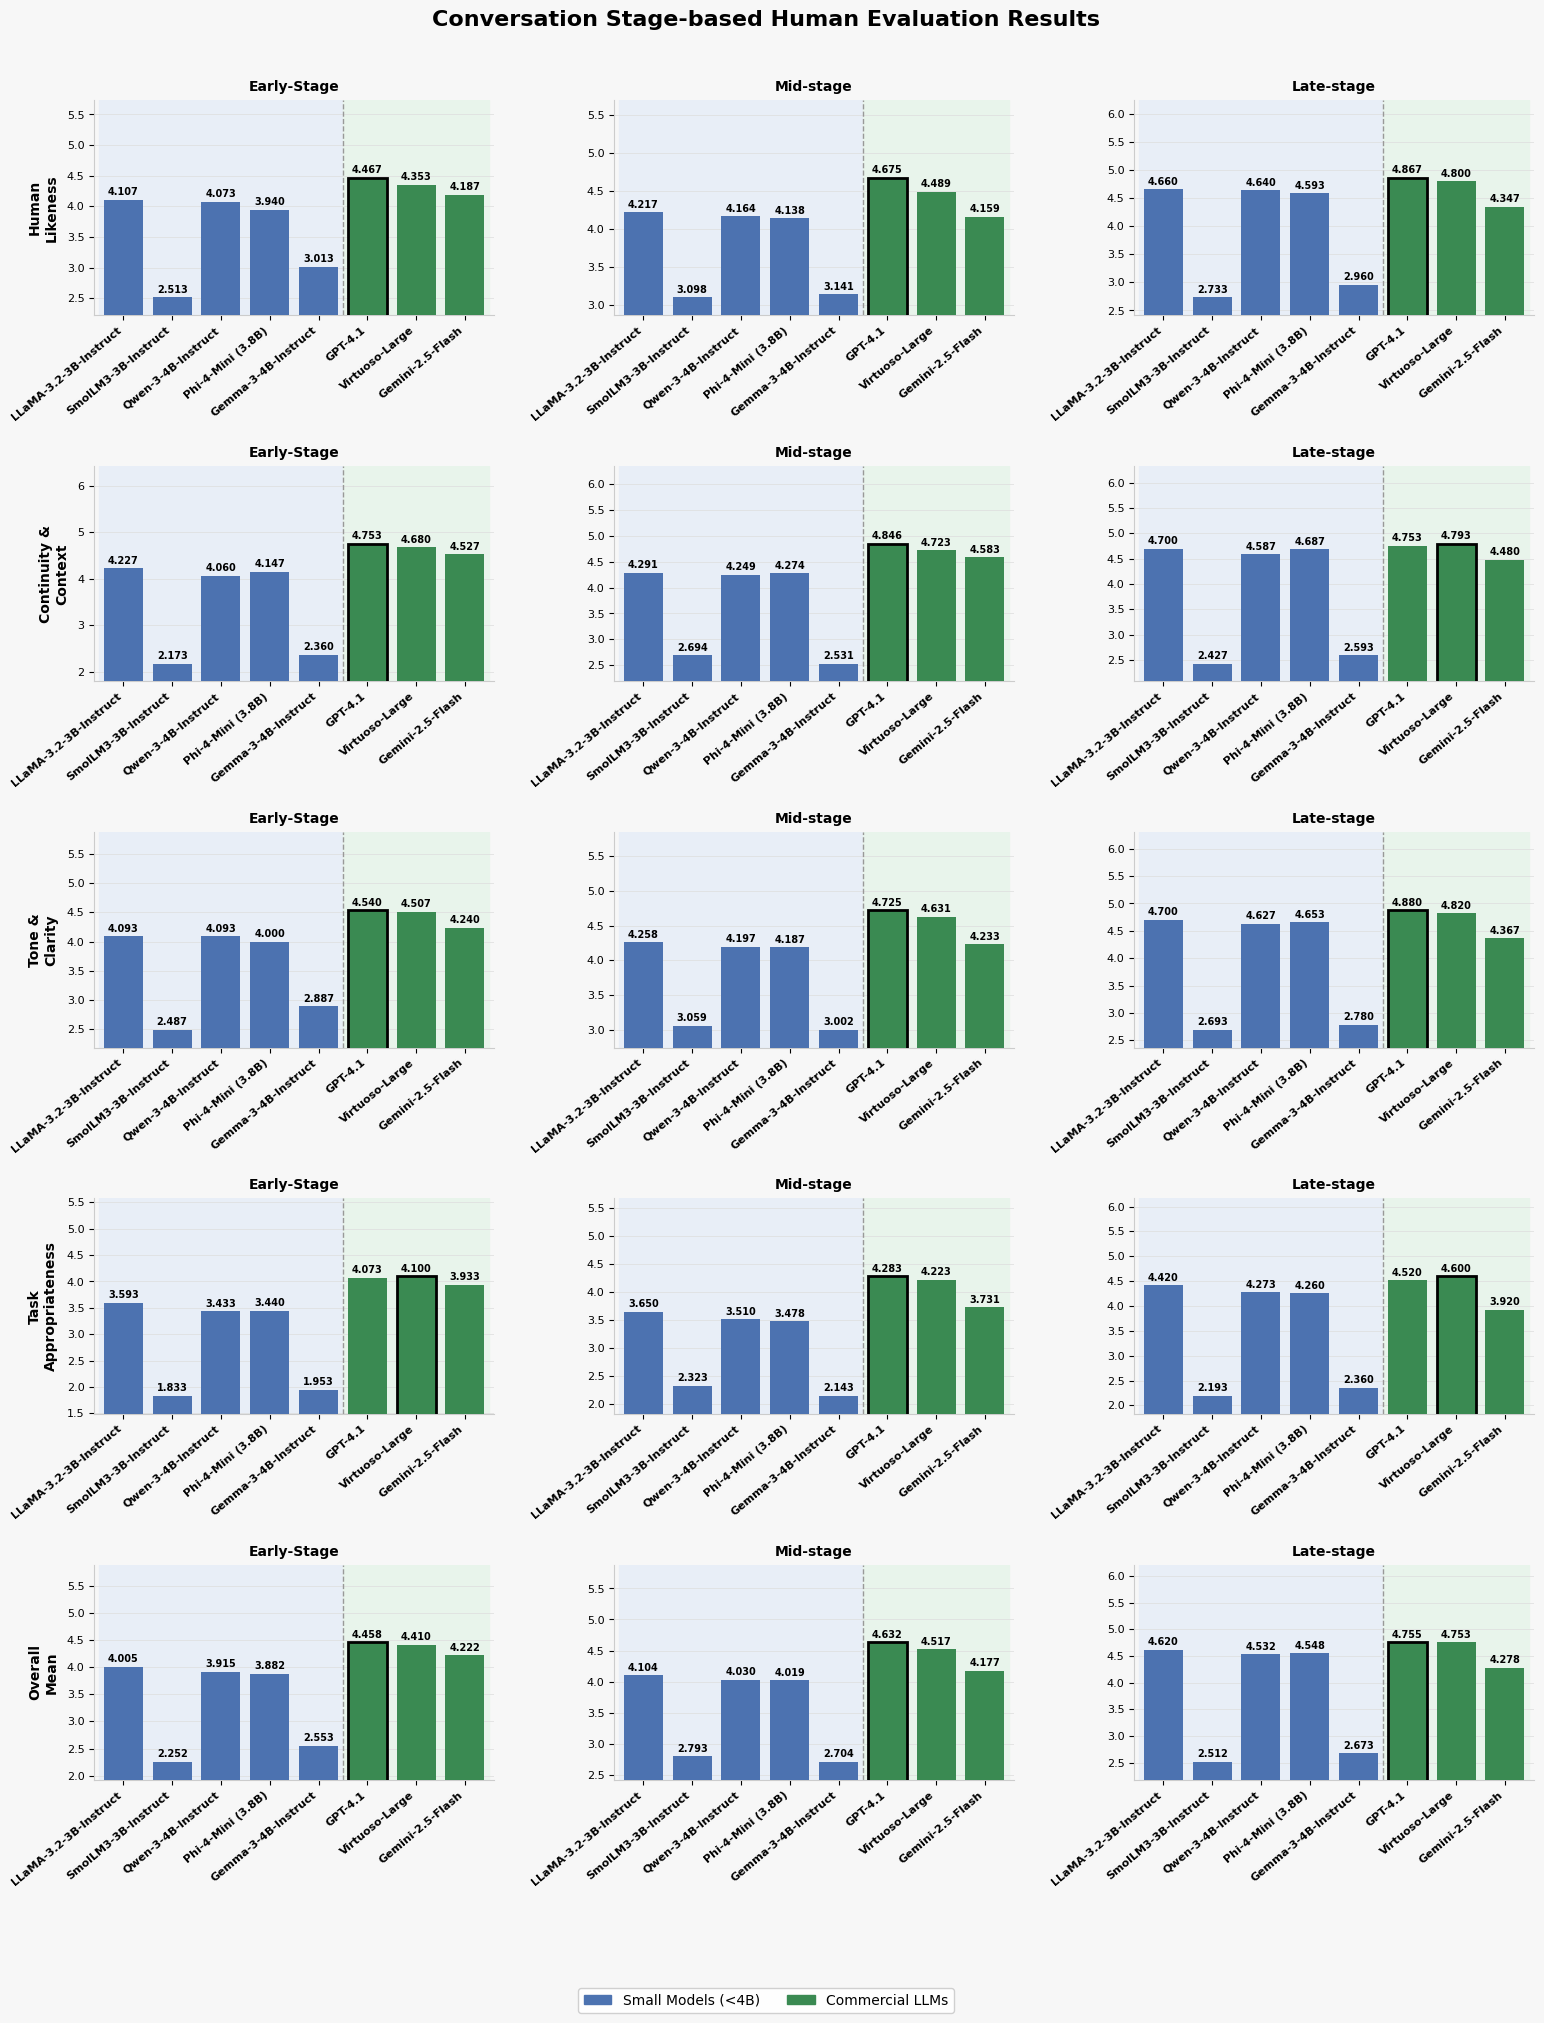

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.gridspec import GridSpec

data = {
    "Early-Stage": [
        ("LLaMA-3.2-3B-Instruct",  4.107, 4.227, 4.093, 3.593, 4.005, "small"),
        ("SmolLM3-3B-Instruct",    2.513, 2.173, 2.487, 1.833, 2.252, "small"),
        ("Qwen-3-4B-Instruct",     4.073, 4.060, 4.093, 3.433, 3.915, "small"),
        ("Phi-4-Mini (3.8B)",      3.940, 4.147, 4.000, 3.440, 3.882, "small"),
        ("Gemma-3-4B-Instruct",    3.013, 2.360, 2.887, 1.953, 2.553, "small"),
        ("GPT-4.1",                4.467, 4.753, 4.540, 4.073, 4.458, "llm"),
        ("Virtuoso-Large",         4.353, 4.680, 4.507, 4.100, 4.410, "llm"),
        ("Gemini-2.5-Flash",       4.187, 4.527, 4.240, 3.933, 4.222, "llm"),
    ],
    "Mid-stage": [
        ("LLaMA-3.2-3B-Instruct",  4.217, 4.291, 4.258, 3.650, 4.104, "small"),
        ("SmolLM3-3B-Instruct",    3.098, 2.694, 3.059, 2.323, 2.793, "small"),
        ("Qwen-3-4B-Instruct",     4.164, 4.249, 4.197, 3.510, 4.030, "small"),
        ("Phi-4-Mini (3.8B)",      4.138, 4.274, 4.187, 3.478, 4.019, "small"),
        ("Gemma-3-4B-Instruct",    3.141, 2.531, 3.002, 2.143, 2.704, "small"),
        ("GPT-4.1",                4.675, 4.846, 4.725, 4.283, 4.632, "llm"),
        ("Virtuoso-Large",         4.489, 4.723, 4.631, 4.223, 4.517, "llm"),
        ("Gemini-2.5-Flash",       4.159, 4.583, 4.233, 3.731, 4.177, "llm"),
    ],
    "Late-stage": [
        ("LLaMA-3.2-3B-Instruct",  4.660, 4.700, 4.700, 4.420, 4.620, "small"),
        ("SmolLM3-3B-Instruct",    2.733, 2.427, 2.693, 2.193, 2.512, "small"),
        ("Qwen-3-4B-Instruct",     4.640, 4.587, 4.627, 4.273, 4.532, "small"),
        ("Phi-4-Mini (3.8B)",      4.593, 4.687, 4.653, 4.260, 4.548, "small"),
        ("Gemma-3-4B-Instruct",    2.960, 2.593, 2.780, 2.360, 2.673, "small"),
        ("GPT-4.1",                4.867, 4.753, 4.880, 4.520, 4.755, "llm"),
        ("Virtuoso-Large",         4.800, 4.793, 4.820, 4.600, 4.753, "llm"),
        ("Gemini-2.5-Flash",       4.347, 4.480, 4.367, 3.920, 4.278, "llm"),
    ],
}

metrics = [
    "Human\nLikeness",
    "Continuity &\nContext",
    "Tone &\nClarity",
    "Task\nAppropriateness",
    "Overall\nMean",
]

stages = list(data.keys())

group_info = [
    ("small", "Small Models (<4B)", "#4C72B0", "#E8EEF7"),
    ("llm",   "Commercial LLMs",    "#3A8A52", "#E8F4EB"),
]

bar_w = 0.80

fig = plt.figure(figsize=(16,20))
fig.patch.set_facecolor("#F7F7F7")

gs = GridSpec(len(metrics), len(stages), figure=fig,
              hspace=0.70, wspace=0.30,
              top=0.93, bottom=0.09, left=0.08, right=0.98)

axes = [[fig.add_subplot(gs[mi, si]) for si in range(len(stages))]
        for mi in range(len(metrics))]

fig.canvas.draw()

for mi in range(len(metrics)):
    for si, stage in enumerate(stages):
        bbox = axes[mi][si].get_position()
        xmid = (bbox.x0 + bbox.x1) / 2
        fig.text(xmid, bbox.y1 + 0.003, stage,
                 ha="center", va="bottom",
                 fontsize=10, fontweight="bold")

fig.suptitle(
    "Conversation Stage-based Human Evaluation Results\n",
    fontsize=16,
    fontweight="bold",
    y=0.975
)

for mi, metric in enumerate(metrics):
    for si, stage in enumerate(stages):

        ax = axes[mi][si]
        rows = data[stage]

        models = [r[0] for r in rows]
        groups = [r[6] for r in rows]
        values = np.array([r[mi+1] for r in rows])

        n = len(models)
        x = np.arange(n)

        ax.set_facecolor("#F7F7F7")

        spans = {}
        for k, *_ in group_info:
            idxs = [i for i,g in enumerate(groups) if g==k]
            if idxs:
                spans[k] = (min(idxs), max(idxs))

        ylo, yhi = values.min(), values.max()
        rng = yhi - ylo if yhi != ylo else 0.01

        ylim_lo = max(0, ylo - rng*0.15)
        ylim_hi = yhi + rng*0.65
        ax.set_ylim(ylim_lo, ylim_hi)

        bar_range = ylim_hi - ylim_lo

        best_i = int(np.argmax(values))

        for k,label,color,shade in group_info:
            if k not in spans:
                continue
            lo,hi = spans[k]
            ax.axvspan(lo-0.5,hi+0.5,color=shade,zorder=0)
            ax.bar(range(lo,hi+1),values[lo:hi+1],
                   width=bar_w,color=color,zorder=3)

        best_group = groups[best_i]
        best_color = next(c for k,l,c,s in group_info if k==best_group)

        ax.bar(best_i,values[best_i],
               width=bar_w,
               color=best_color,
               edgecolor="black",
               linewidth=2.0,
               zorder=4)

        for k,*_ in group_info[:-1]:
            if k in spans:
                _,hi = spans[k]
                ax.axvline(hi+0.5,color="#999999",
                           linestyle="--",linewidth=1.0)

        for i,val in enumerate(values):
            ax.text(i,val + bar_range*0.012,
                    f"{val:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    fontweight="bold")

        ax.set_xlim(-0.6,n-0.4)
        ax.set_xticks(x)

        ax.set_xticklabels(
            models,
            rotation=40,
            ha="right",
            fontsize=8,
            fontweight="bold"
        )

        ax.tick_params(axis="y", labelsize=8)

        ax.spines[["top","right"]].set_visible(False)
        ax.spines[["bottom","left"]].set_color("#CCCCCC")

        ax.grid(axis="y",color="#DDDDDD",linewidth=0.5)

        if si == 0:
            ax.set_ylabel(metric,
                          fontsize=10,
                          fontweight="bold",
                          labelpad=6)

legend_patches = [
    mpatches.Patch(color=c,label=l)
    for k,l,c,s in group_info
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=2,
    fontsize=10,
    framealpha=0.9,
    edgecolor="#CCCCCC",
    bbox_to_anchor=(0.5,-0.03)
)

plt.show()

/tmp/ipykernel_147/3637501620.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


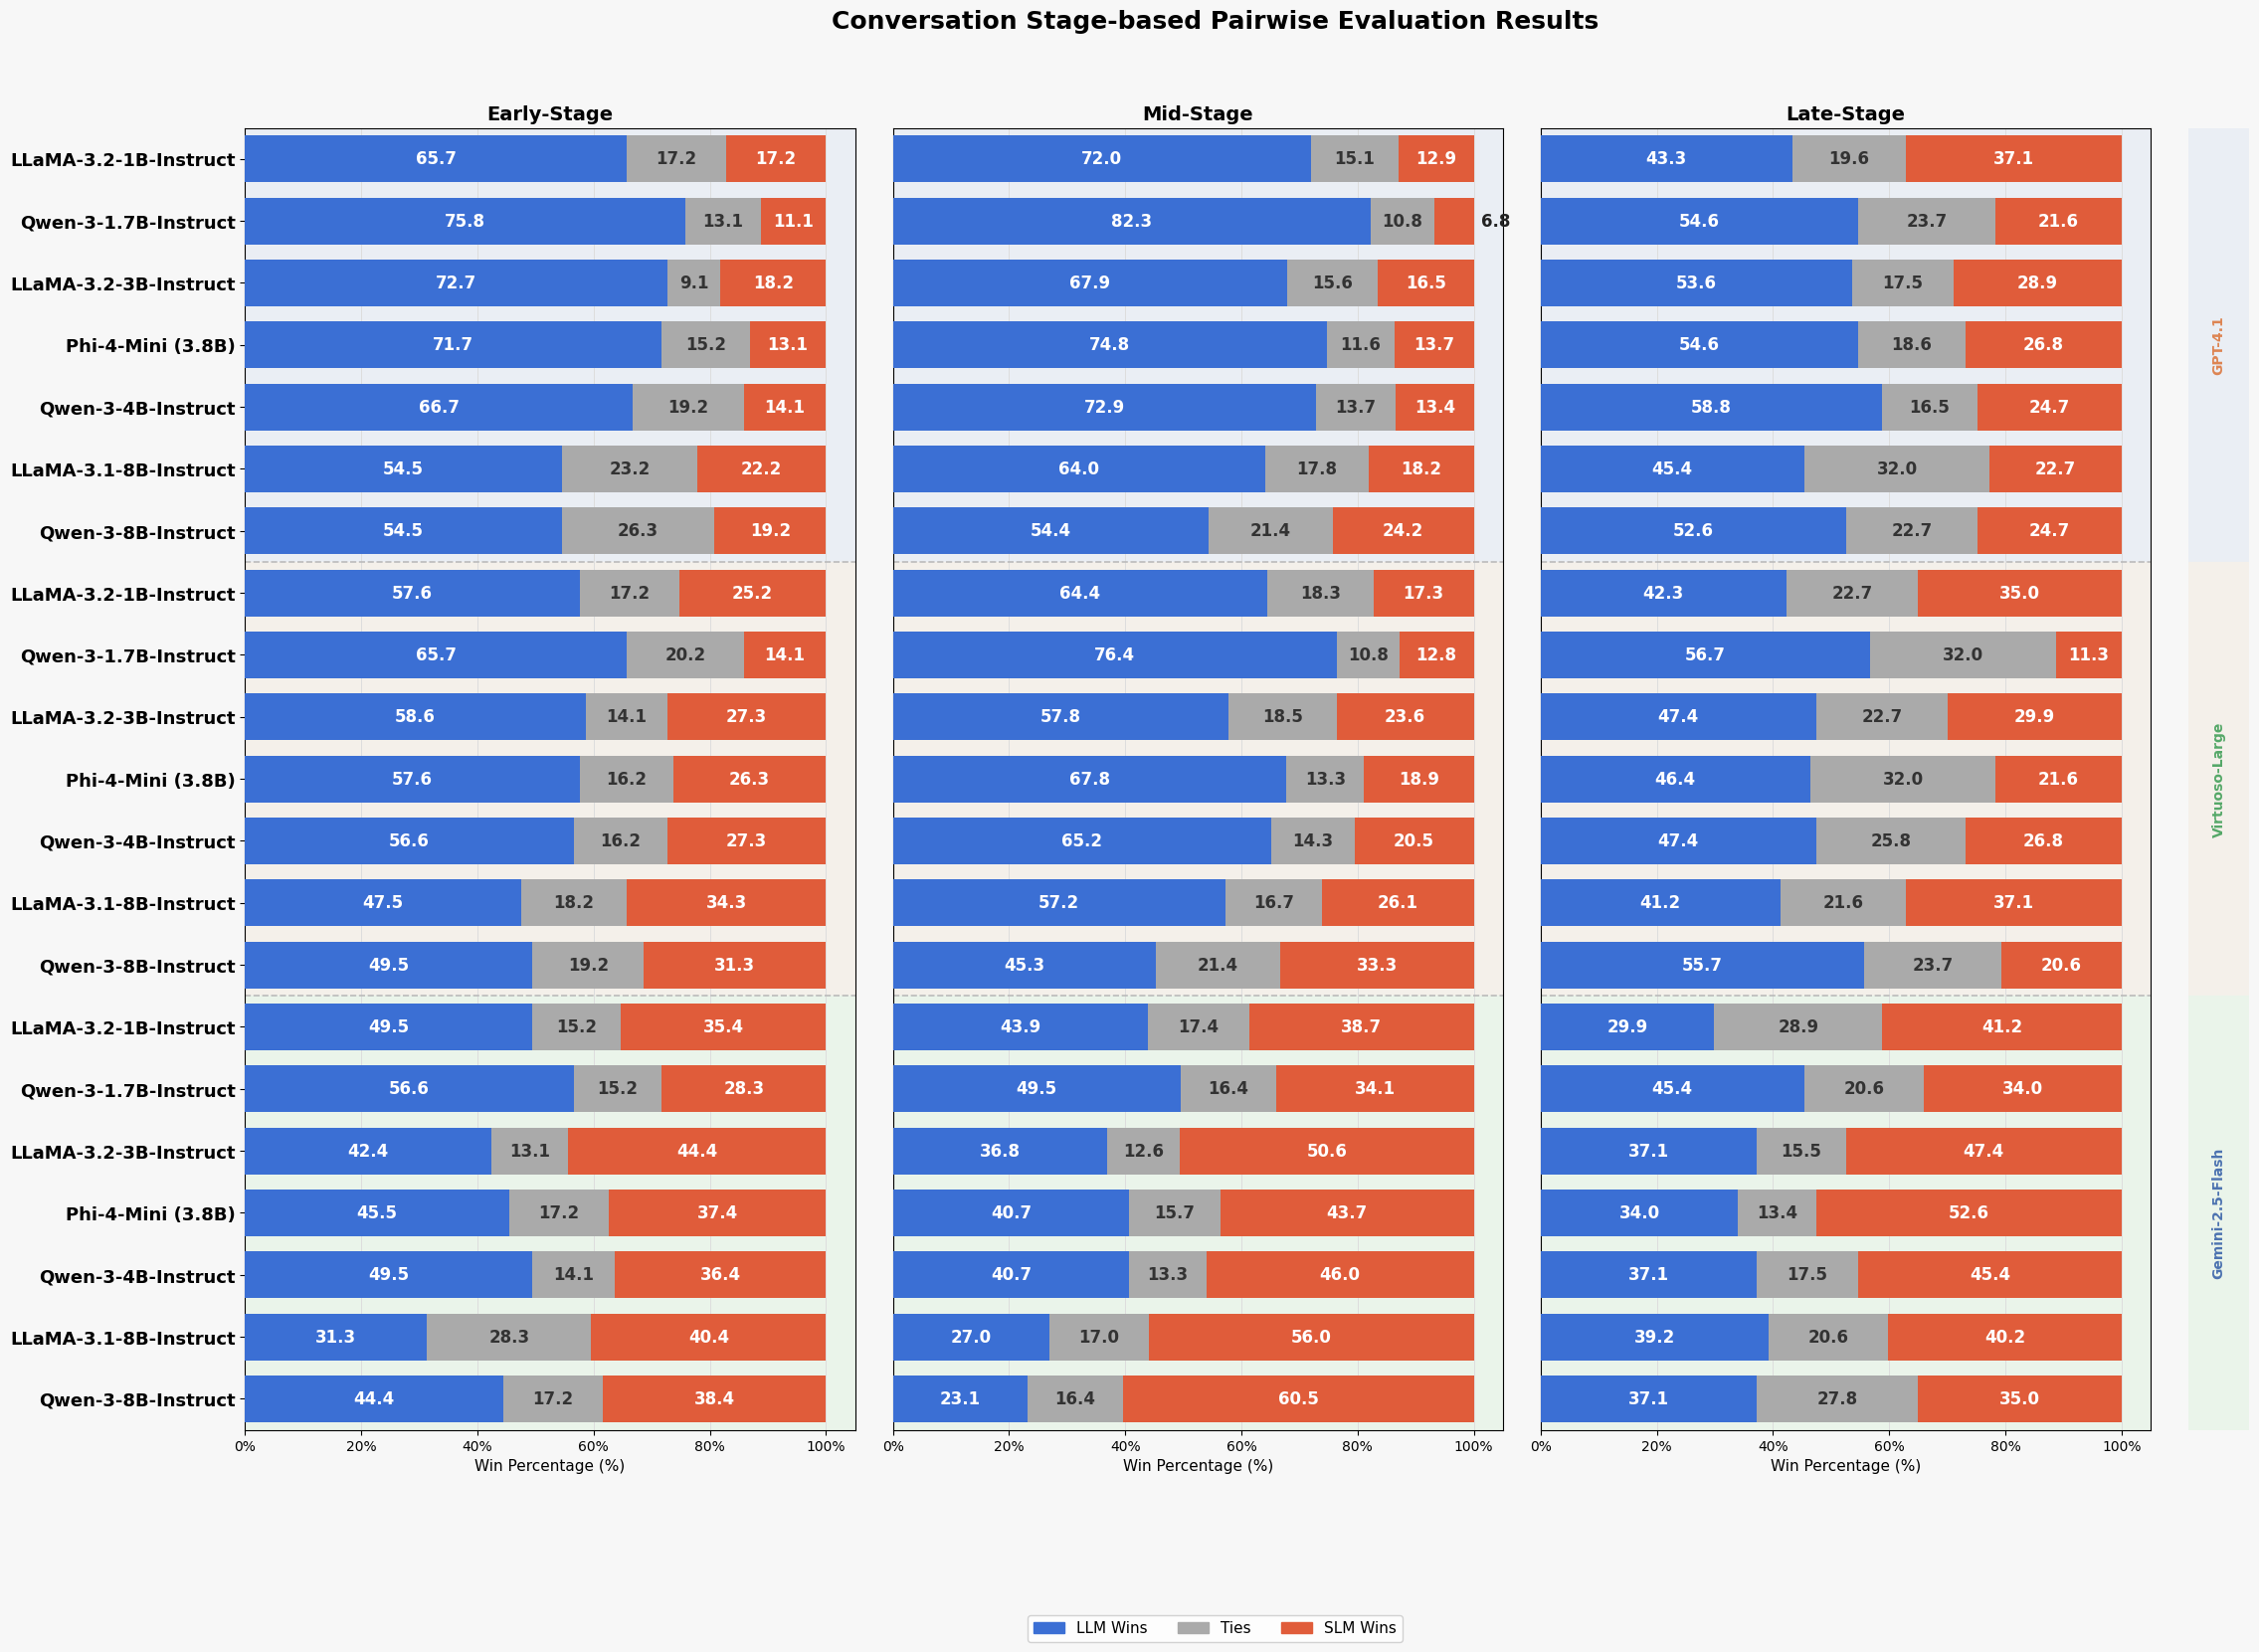

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ── Data ──────────────────────────────────────────────────────────
data = [
    ("GPT-4.1", "LLaMA-3.2-1B-Instruct", 65.66,17.17,17.17, 72.01,12.94,15.05, 43.30,37.11,19.59),
    ("GPT-4.1", "Qwen-3-1.7B-Instruct",  75.76,11.11,13.13, 82.34, 6.84,10.82, 54.64,21.65,23.71),
    ("GPT-4.1", "LLaMA-3.2-3B-Instruct", 72.73,18.18, 9.09, 67.91,16.54,15.55, 53.61,28.87,17.53),
    ("GPT-4.1", "Phi-4-Mini (3.8B)",     71.72,13.13,15.15, 74.75,13.68,11.57, 54.64,26.80,18.56),
    ("GPT-4.1", "Qwen-3-4B-Instruct",    66.67,14.14,19.19, 72.89,13.43,13.68, 58.76,24.74,16.49),
    ("GPT-4.1", "LLaMA-3.1-8B-Instruct", 54.55,22.22,23.23, 64.05,18.16,17.79, 45.36,22.68,31.96),
    ("GPT-4.1", "Qwen-3-8B-Instruct",    54.55,19.19,26.26, 54.35,24.25,21.39, 52.58,24.74,22.68),

    ("Virtuoso-Large", "LLaMA-3.2-1B-Instruct", 57.58,25.25,17.17, 64.43,17.29,18.28, 42.27,35.05,22.68),
    ("Virtuoso-Large", "Qwen-3-1.7B-Instruct",  65.66,14.14,20.20, 76.37,12.81,10.82, 56.70,11.34,31.96),
    ("Virtuoso-Large", "LLaMA-3.2-3B-Instruct", 58.59,27.27,14.14, 57.84,23.63,18.53, 47.42,29.90,22.68),
    ("Virtuoso-Large", "Phi-4-Mini (3.8B)",     57.58,26.26,16.16, 67.79,18.91,13.31, 46.39,21.65,31.96),
    ("Virtuoso-Large", "Qwen-3-4B-Instruct",    56.57,27.27,16.16, 65.17,20.52,14.30, 47.42,26.80,25.77),
    ("Virtuoso-Large", "LLaMA-3.1-8B-Instruct", 47.47,34.34,18.18, 57.21,26.12,16.67, 41.24,37.11,21.65),
    ("Virtuoso-Large", "Qwen-3-8B-Instruct",    49.49,31.31,19.19, 45.27,33.33,21.39, 55.67,20.62,23.71),

    ("Gemini-2.5-Flash", "LLaMA-3.2-1B-Instruct", 49.49,35.35,15.15, 43.91,38.68,17.41, 29.90,41.24,28.87),
    ("Gemini-2.5-Flash", "Qwen-3-1.7B-Instruct",  56.57,28.28,15.15, 49.50,34.08,16.42, 45.36,34.02,20.62),
    ("Gemini-2.5-Flash", "LLaMA-3.2-3B-Instruct", 42.42,44.44,13.13, 36.82,50.62,12.56, 37.11,47.42,15.46),
    ("Gemini-2.5-Flash", "Phi-4-Mini (3.8B)",     45.45,37.37,17.17, 40.67,43.66,15.67, 34.02,52.58,13.40),
    ("Gemini-2.5-Flash", "Qwen-3-4B-Instruct",    49.49,36.36,14.14, 40.67,46.02,13.31, 37.11,45.36,17.53),
    ("Gemini-2.5-Flash", "LLaMA-3.1-8B-Instruct", 31.31,40.40,28.28, 26.99,55.97,17.04, 39.18,40.21,20.62),
    ("Gemini-2.5-Flash", "Qwen-3-8B-Instruct",    44.44,38.38,17.17, 23.13,60.45,16.42, 37.11,35.05,27.84),
]

llm_groups = ["GPT-4.1", "Virtuoso-Large", "Gemini-2.5-Flash"]
group_colors = {"GPT-4.1":"#DD8452","Virtuoso-Large":"#55A868","Gemini-2.5-Flash":"#4C72B0"}
group_boundaries=[0,7,14,21]

stages=["Early-Stage","Mid-Stage","Late-Stage"]
stage_cols=[(2,3,4),(5,6,7),(8,9,10)]

slms=[d[1] for d in data]
n=len(data)
y=np.arange(n)

shades={0:"#EAEEF4",1:"#F4F0EA",2:"#EAF4EA"}

fig=plt.figure(figsize=(26,17))
fig.patch.set_facecolor("#F7F7F7")

gs=gridspec.GridSpec(1,4,figure=fig,width_ratios=[10,10,10,1],wspace=0.08)
axs=[fig.add_subplot(gs[0,i]) for i in range(3)]
ax_lbl=fig.add_subplot(gs[0,3])

height=0.75

for si,(stage,(ci_llm,ci_slm,ci_tie)) in enumerate(zip(stages,stage_cols)):
    ax=axs[si]

    llm_w=np.array([d[ci_llm] for d in data])
    slm_w=np.array([d[ci_slm] for d in data])
    ties=np.array([d[ci_tie] for d in data])

    for gi in range(len(llm_groups)):
        lo,hi=group_boundaries[gi],group_boundaries[gi+1]
        ax.axhspan(lo-0.5,hi-0.5,color=shades[gi],zorder=0)

    ax.barh(y,llm_w,height=height,color="#3B6FD4",zorder=3)
    ax.barh(y,ties,left=llm_w,height=height,color="#AAAAAA",zorder=3)
    ax.barh(y,slm_w,left=llm_w+ties,height=height,color="#E05C3A",zorder=3)

    # Improved label placement
    for i in range(n):

        if llm_w[i]>=6:
            ax.text(llm_w[i]/2,i,f"{llm_w[i]:.1f}",ha="center",va="center",
                    fontsize=12,color="white",fontweight="bold")

        if ties[i]>=6:
            ax.text(llm_w[i]+ties[i]/2,i,f"{ties[i]:.1f}",ha="center",va="center",
                    fontsize=12,color="#333333",fontweight="bold")

        if slm_w[i]>=6:
            if slm_w[i]<10:
                ax.text(llm_w[i]+ties[i]+slm_w[i]+1.2,i,f"{slm_w[i]:.1f}",
                        ha="left",va="center",fontsize=12,color="#222222",fontweight="bold")
            else:
                ax.text(llm_w[i]+ties[i]+slm_w[i]/2,i,f"{slm_w[i]:.1f}",
                        ha="center",va="center",fontsize=12,color="white",fontweight="bold")

    for b in group_boundaries[1:-1]:
        ax.axhline(b-0.5,color="#BBBBBB",linewidth=1.2,linestyle="--")

    ax.set_ylim(n-0.5,-0.5)
    ax.set_xlim(0,105)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{int(v)}%"))
    ax.set_xlabel("Win Percentage (%)",fontsize=11)
    ax.grid(axis="x",color="#DDDDDD",linewidth=0.7)

    if si==0:
        ax.set_yticks(y)
        ax.set_yticklabels(slms,fontsize=13,fontweight="bold")
    else:
        ax.set_yticks([])

    ax.set_title(stage,fontsize=14,fontweight="bold")

# Right strip
ax_lbl.set_xlim(0,1)
ax_lbl.set_ylim(n-0.5,-0.5)
ax_lbl.axis("off")

for gi,llm in enumerate(llm_groups):
    lo,hi=group_boundaries[gi],group_boundaries[gi+1]
    mid=(lo+hi-1)/2
    ax_lbl.axhspan(lo-0.5,hi-0.5,color=shades[gi])
    ax_lbl.text(0.5,mid,llm,ha="center",va="center",rotation=90,
                fontsize=10,fontweight="bold",color=group_colors[llm])

legend_patches=[
    mpatches.Patch(color="#3B6FD4",label="LLM Wins"),
    mpatches.Patch(color="#AAAAAA",label="Ties"),
    mpatches.Patch(color="#E05C3A",label="SLM Wins")
]

fig.legend(handles=legend_patches,loc="lower center",ncol=3,
           fontsize=11,framealpha=0.85,edgecolor="#CCCCCC",
           bbox_to_anchor=(0.5,-0.02))

fig.suptitle("Conversation Stage-based Pairwise Evaluation Results",
             fontsize=18,fontweight="bold",y=0.95)

plt.tight_layout()
plt.show()

## Cost Benchmarking

/tmp/ipykernel_147/4161323315.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.06,1,1])


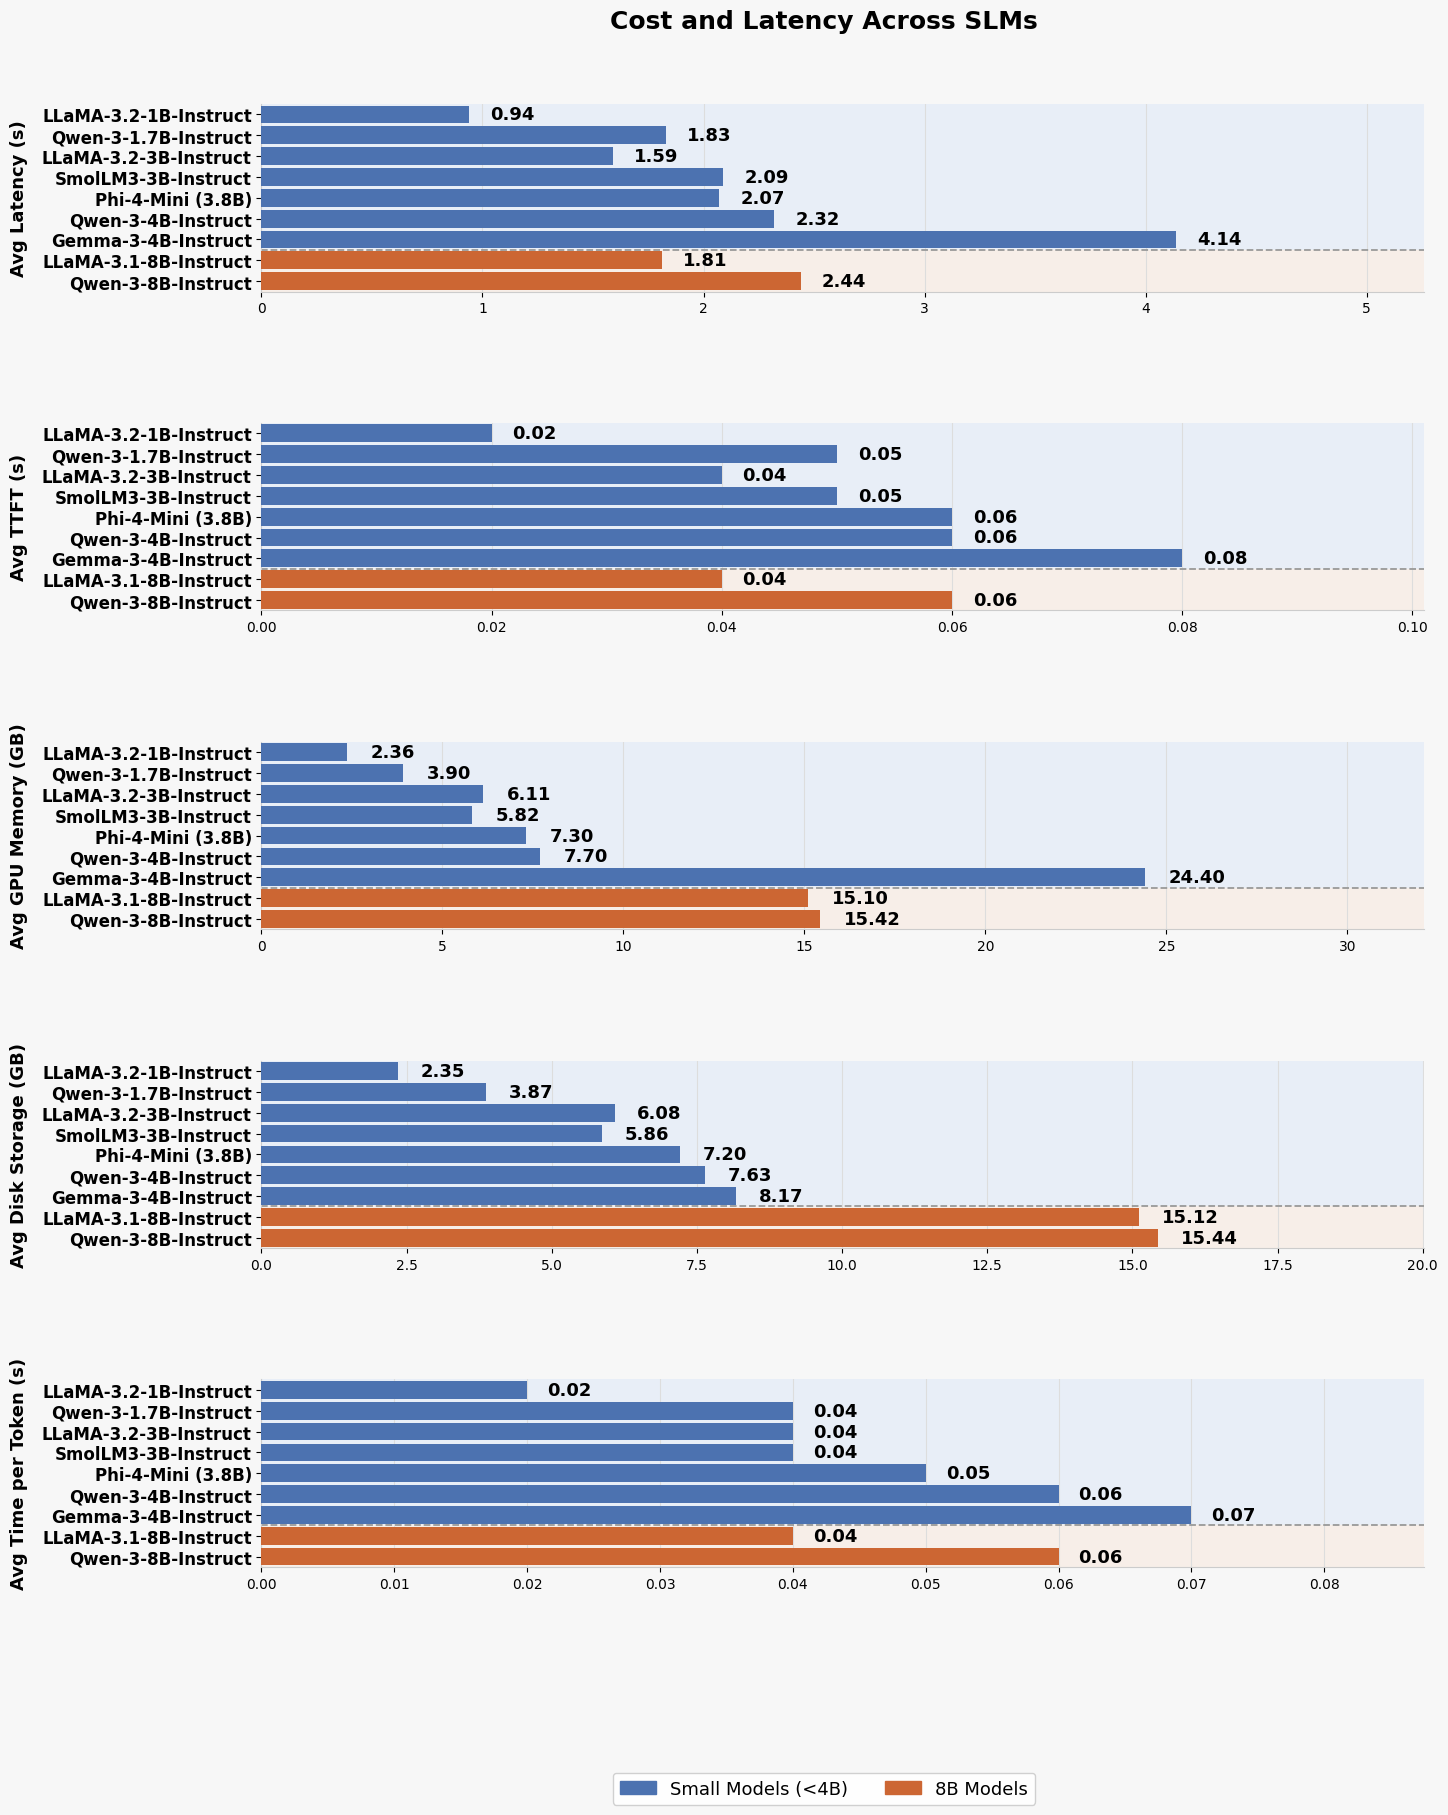

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data from Table 7.8 ───────────────────────────
rows = [
    ("LLaMA-3.2-1B-Instruct", 0.94,0.02,2.36,2.35,0.02,"small"),
    ("Qwen-3-1.7B-Instruct",  1.83,0.05,3.90,3.87,0.04,"small"),
    ("LLaMA-3.2-3B-Instruct", 1.59,0.04,6.11,6.08,0.04,"small"),
    ("SmolLM3-3B-Instruct",   2.09,0.05,5.82,5.86,0.04,"small"),
    ("Phi-4-Mini (3.8B)",     2.07,0.06,7.30,7.20,0.05,"small"),
    ("Qwen-3-4B-Instruct",    2.32,0.06,7.70,7.63,0.06,"small"),
    ("Gemma-3-4B-Instruct",   4.14,0.08,24.40,8.17,0.07,"small"),

    ("LLaMA-3.1-8B-Instruct", 1.81,0.04,15.10,15.12,0.04,"8b"),
    ("Qwen-3-8B-Instruct",    2.44,0.06,15.42,15.44,0.06,"8b"),
]

models = [r[0] for r in rows]
groups = [r[6] for r in rows]

metrics = [
    "Avg Latency (s)",
    "Avg TTFT (s)",
    "Avg GPU Memory (GB)",
    "Avg Disk Storage (GB)",
    "Avg Time per Token (s)"
]

vals = {m: np.array([r[i+1] for r in rows]) for i, m in enumerate(metrics)}

group_info = [
    ("small","Small Models (<4B)","#4C72B0","#E8EEF7"),
    ("8b","8B Models","#CC6633","#F7EEE8")
]

n = len(models)
y = np.arange(n)

# Find span indices for shading
spans = {}
for k,*_ in group_info:
    idx=[i for i,g in enumerate(groups) if g==k]
    spans[k]=(min(idx),max(idx))

# ── Figure ───────────────────────────
fig, axes = plt.subplots(
    5,1,
    figsize=(15,19),                # larger figure
    gridspec_kw={"hspace":0.7}
)

fig.patch.set_facecolor("#F7F7F7")

for metric, ax in zip(metrics, axes):

    v = vals[metric]

    ylo, yhi = v.min(), v.max()
    rng = yhi - ylo if yhi != ylo else 0.01

    ax.set_xlim(0, yhi + rng*0.35)

    # Group shading + bars
    for k,label,color,shade in group_info:

        lo,hi = spans[k]

        ax.axhspan(lo-0.5,hi+0.5,color=shade,zorder=0)

        idx=list(range(lo,hi+1))

        # thicker bars
        ax.barh(idx,v[idx],color=color,height=0.85,zorder=3)

    # Group separator
    for k,*_ in group_info[:-1]:

        _,hi = spans[k]

        ax.axhline(hi+0.5,
                   color="#999999",
                   linestyle="--",
                   linewidth=1.3)

    # Value labels (larger)
    for i,val in enumerate(v):

        ax.text(val+rng*0.03,i,f"{val:.2f}",
                va="center",
                fontsize=13,
                fontweight="bold")

    ax.set_ylabel(metric,
                  fontsize=13,
                  fontweight="bold",
                  labelpad=10)

    ax.grid(axis="x",color="#DDDDDD")

    ax.spines[["top","right"]].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")

    ax.set_ylim(n-0.5,-0.5)

    ax.set_yticks(y)
    ax.set_yticklabels(models,
                       fontsize=12,
                       fontweight="bold")

# ── Title ───────────────────────────
fig.suptitle(
"Cost and Latency Across SLMs",
fontsize=18,
fontweight="bold",
y=0.93
)

# ── Legend ───────────────────────────
legend_patches = [
    mpatches.Patch(color=c,label=l)
    for k,l,c,s in group_info
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=2,
    fontsize=13,
    framealpha=0.9,
    edgecolor="#CCCCCC",
    bbox_to_anchor=(0.5,-0.02)
)

# ── Layout adjustment
plt.tight_layout(rect=[0,0.06,1,1])

plt.show()